## Importing libraries & datasets

In [1]:
# Basic utilities
import os
import random
import shutil
import zipfile
from io import BytesIO
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image handling
from PIL import Image
from skimage.color import rgb2lab, rgb2gray

# Progress bar
from tqdm import tqdm

# SciPy
from scipy.stats import chi2_contingency, rankdata
from scipy.special import logit, expit

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    silhouette_score,
    RocCurveDisplay,
)

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# PyTorch data utilities
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Mixed precision
from torch.cuda.amp import GradScaler, autocast

# Torchvision
from torchvision import transforms, datasets, models
from torchvision.transforms import functional as TF

# EfficientNet / timm
import timm

In [2]:
# Check for GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


In [3]:
# Import and read dataset
DATASET_PATH = "."

TRAIN_IMAGES_ZIP = os.path.join(DATASET_PATH, "./Datasets/ISIC_2020_Training_JPEG.zip")
TEST_IMAGES_ZIP = os.path.join(DATASET_PATH, "./Datasets/ISIC_2019_Test_Input.zip")
TRAIN_METADATA_PATH = os.path.join(DATASET_PATH, "./Datasets/ISIC_2020_Training_Metadata.csv")
TEST_METADATA_PATH = os.path.join(DATASET_PATH, "./Datasets/ISIC_2019_Test_Metadata.csv")

# Open zip files 
train_zip = zipfile.ZipFile(TRAIN_IMAGES_ZIP, 'r')
test_zip = zipfile.ZipFile(TEST_IMAGES_ZIP, 'r')

# Read metadata
train_metadata = pd.read_csv(TRAIN_METADATA_PATH)
test_metadata = pd.read_csv(TEST_METADATA_PATH)
print("Train Metadata:", train_metadata.shape)
print("Test Metadata:", test_metadata.shape)

Train Metadata: (33126, 8)
Test Metadata: (8238, 4)


## Data cleaning/verification & EDA
- Matching each image with its corresponding ID in metadata file. If not matched, exclude from dataset.

In [4]:
# Verify images & metadata matches
train_metadata['image_name_with_ext'] = train_metadata['image_name'] + '.jpg'
train_zip_contents = train_zip.namelist()
train_image_files = set([os.path.basename(f) for f in train_zip_contents if f.endswith('.jpg')])

test_metadata['image_name_with_ext'] = test_metadata['image'] + '.jpg'

filtered_metadata = train_metadata[train_metadata['image_name_with_ext'].isin(train_image_files)]
print("\nMetadata Size After Validation:", len(filtered_metadata))


Metadata Size After Validation: 33126


In [5]:
filtered_metadata.columns

Index(['image_name', 'patient_id', 'sex', 'age_approx',
       'anatom_site_general_challenge', 'diagnosis', 'benign_malignant',
       'target', 'image_name_with_ext'],
      dtype='object')

In [6]:
# Multi-class Distribution
class_counts = filtered_metadata['diagnosis'].value_counts()
class_counts

diagnosis
unknown                               27124
nevus                                  5193
melanoma                                584
seborrheic keratosis                    135
lentigo NOS                              44
lichenoid keratosis                      37
solar lentigo                             7
cafe-au-lait macule                       1
atypical melanocytic proliferation        1
Name: count, dtype: int64

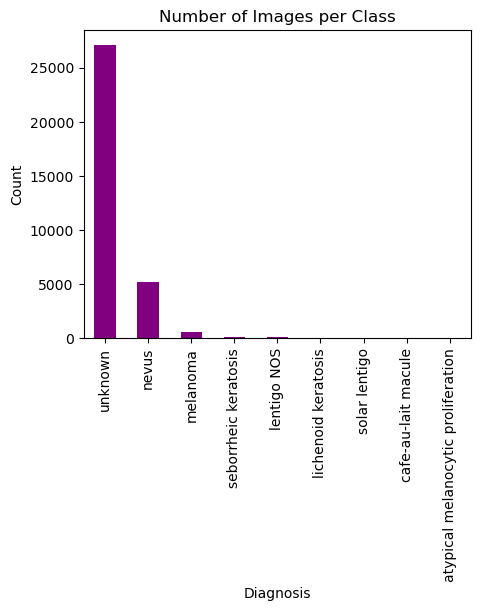

In [7]:
# Plot multi-class distribution
plt.figure(figsize=(5, 4))
class_counts.plot(kind='bar', color=['purple'])
plt.title('Number of Images per Class')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

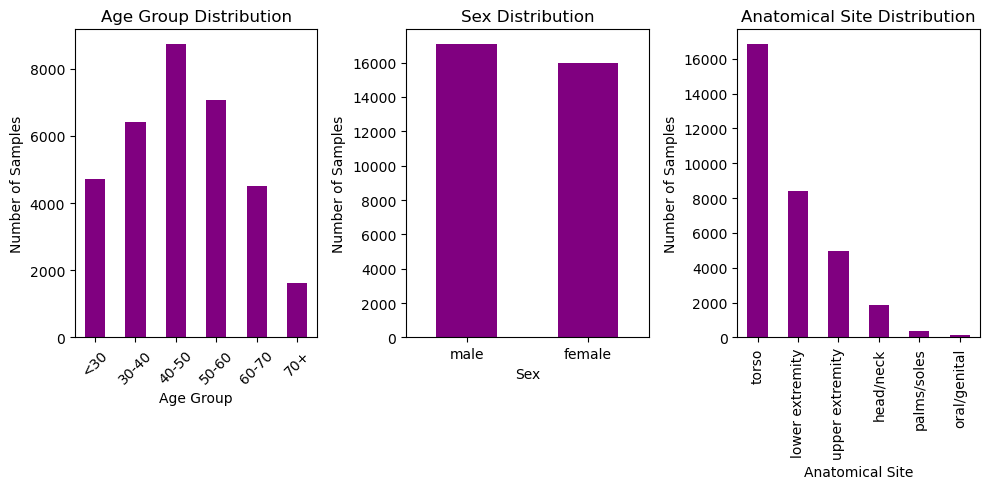

In [8]:
# General Data distribution
filtered_metadata['age_group'] = pd.cut(filtered_metadata['age_approx'],bins=[0, 30, 40, 50, 60, 70, 100],
                                        labels=['<30', '30-40', '40-50', '50-60', '60-70', '70+'])
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# Age group distribution
filtered_metadata['age_group'].value_counts().sort_index().plot(kind='bar', color='purple', ax=axes[0])
axes[0].set_title('Age Group Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)

# Sex distribution
filtered_metadata['sex'].value_counts().plot(kind='bar', color='purple', ax=axes[1])
axes[1].set_title('Sex Distribution')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Number of Samples')
axes[1].tick_params(axis='x', rotation=0)

# Anatomical site distribution
filtered_metadata['anatom_site_general_challenge'].value_counts().plot(kind='bar', color='purple', ax=axes[2])
axes[2].set_title('Anatomical Site Distribution')
axes[2].set_xlabel('Anatomical Site')
axes[2].set_ylabel('Number of Samples')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


/tmp/ipykernel_416/393945843.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  melanoma_by_age = filtered_metadata.groupby('age_group')['benign_malignant'].apply(lambda x: (x == 'malignant').sum() / len(x) * 100)


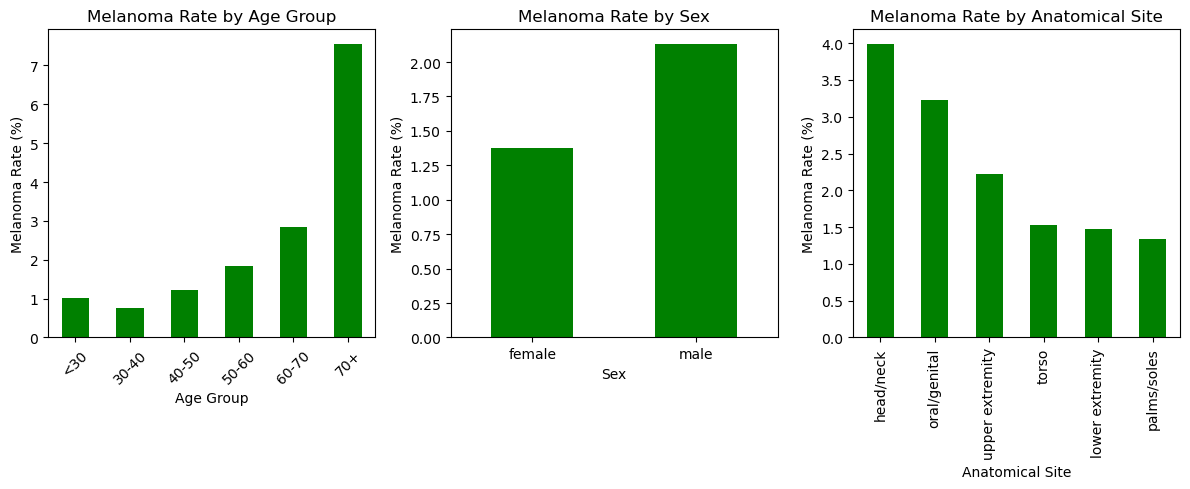

In [9]:
# Melanoma Rate by age groups, sex, and anatomical positions
filtered_metadata['age_group'] = pd.cut(filtered_metadata['age_approx'], 
                                          bins=[0, 30, 40, 50, 60, 70, 100],
                                          labels=['<30', '30-40', '40-50', '50-60', '60-70', '70+']) # Bin age into ranges

melanoma_by_age = filtered_metadata.groupby('age_group')['benign_malignant'].apply(lambda x: (x == 'malignant').sum() / len(x) * 100)
melanoma_by_sex = filtered_metadata.groupby('sex')['benign_malignant'].apply(lambda x: (x == 'malignant').sum() / len(x) * 100)
melanoma_by_site = filtered_metadata.groupby('anatom_site_general_challenge')['benign_malignant'].apply(
    lambda x: (x == 'malignant').sum() / len(x) * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Age Group
melanoma_by_age.plot(kind='bar', color='green', ax=axes[0])
axes[0].set_title('Melanoma Rate by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Melanoma Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Sex
melanoma_by_sex.plot(kind='bar', color=['green'], ax=axes[1])
axes[1].set_title('Melanoma Rate by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Melanoma Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

# Anatomical Site
melanoma_by_site.plot(kind='bar', color='green', ax=axes[2])
axes[2].set_title('Melanoma Rate by Anatomical Site')
axes[2].set_xlabel('Anatomical Site')
axes[2].set_ylabel('Melanoma Rate (%)')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Association of melanoma rate and pateints demographic
The chi-square analyses indicate statistically significant associations between both sex and malignancy (χ² = 26.65, p < 0.001) and anatomical site and malignancy (χ² = 70.75, p < 0.001). These results suggest that malignancy status is not independent of either patient sex or lesion anatomical location.

In [10]:
# CHI-SQUARE test: 

# Sex vs Malignancy
contingency_sex = pd.crosstab(filtered_metadata['sex'], filtered_metadata['benign_malignant'])
chi2, p_value, dof, expected = chi2_contingency(contingency_sex)
print(f"\nChi-square test (Sex vs Malignancy):")
print(f"Chi2 statistic: {chi2:.4f}, p-value: {p_value:.4f}")

# Anatomical Site vs Malignancy
contingency_site = pd.crosstab(filtered_metadata['anatom_site_general_challenge'], filtered_metadata['benign_malignant'])
chi2, p_value, dof, expected = chi2_contingency(contingency_site)
print(f"\nChi-square test (Anatomical Site vs Malignancy):")
print(f"Chi2 statistic: {chi2:.4f}, p-value: {p_value:.4f}")


Chi-square test (Sex vs Malignancy):
Chi2 statistic: 26.6534, p-value: 0.0000

Chi-square test (Anatomical Site vs Malignancy):
Chi2 statistic: 70.7495, p-value: 0.0000


In [11]:
# Benign vs Malignant count
diagnosis_count = filtered_metadata['benign_malignant'].value_counts()
diagnosis_count

benign_malignant
benign       32542
malignant      584
Name: count, dtype: int64

# A Peak into Dermoscopic Images

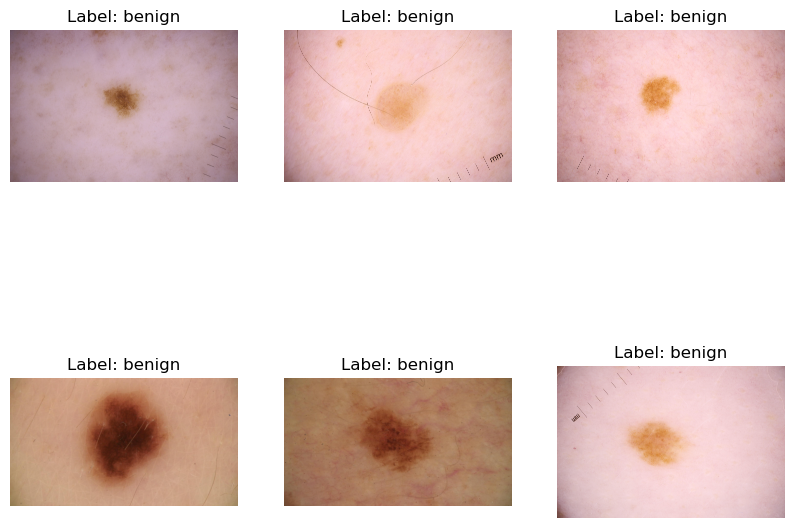

In [14]:
# Visualizing sample images from dataset
def visualize_samples(zip_file, folder_name, metadata, num_samples=6):
    if metadata.empty:
        print("\nNo valid samples to visualize.")
        return
    
    sample_images = metadata.sample(num_samples)
    plt.figure(figsize=(10, 8))
    
    for idx, (_, row) in enumerate(sample_images.iterrows()):
        img_path = f"{folder_name}/{row['image_name_with_ext']}"
        
        with zip_file.open(img_path) as file:
            image = Image.open(BytesIO(file.read())).convert('RGB')
        
        plt.subplot(2, 3, idx + 1)
        plt.imshow(image)
        plt.title(f"Label: {row['benign_malignant']}") # Include labels
        plt.axis("off")
    
    plt.show()

visualize_samples(train_zip, 'train', filtered_metadata)

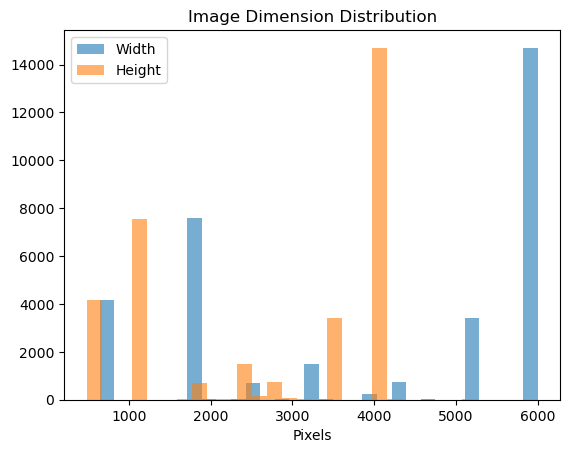

In [13]:
# Image dimension distribution
sizes = filtered_metadata['image_name_with_ext'].apply(
    lambda x: Image.open(BytesIO(train_zip.read(f"train/{x}"))).size)

widths, heights = zip(*sizes)
plt.hist(widths, bins=30, alpha=0.6, label='Width')
plt.hist(heights, bins=30, alpha=0.6, label='Height')
plt.xlabel('Pixels')
plt.legend()
plt.title("Image Dimension Distribution")
plt.show()

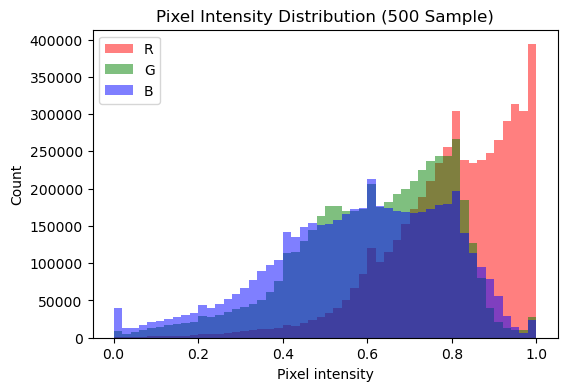

In [15]:
# Pixel Intensity Distribution in RGB
means = []
for x in filtered_metadata['image_name_with_ext'].sample(500, random_state=42):
    with train_zip.open(f"train/{x}") as file:
        img = Image.open(BytesIO(file.read())).convert('RGB')
        img = np.array(img).astype(np.float32) / 255.0
        flat_img = img.reshape(-1, 3)
        sample_indices = np.random.choice(len(flat_img), size=min(10000, len(flat_img)), replace=False) # 10,000 pixel per image
        means.append(flat_img[sample_indices])

pixels = np.vstack(means)

plt.figure(figsize=(6,4))
for i, (c, color) in enumerate(zip(['R', 'G', 'B'], ['red', 'green', 'blue'])):
    plt.hist(pixels[:, i], bins=50, alpha=0.5, label=c, color=color)
plt.legend()
plt.title("Pixel Intensity Distribution (500 Sample)")
plt.xlabel("Pixel intensity")
plt.ylabel("Count")
plt.show()

# Feature Engineer # 1

## Our Choice of CNN (ResNet50) – Preprocessing Requirements

- The ResNet50 architecture requires:
  - Uniform image dimensions  
  - Pixel intensity normalization  

**Image Resizing**
- Resize images to 224 × 224  
- Use black padding to preserve aspect ratio  
- Avoid distortion and maintain lesion integrity  

**Pixel Normalization**
- Apply ImageNet RGB mean normalization  
  - Mean: [0.485, 0.456, 0.406]  
  - Std: [0.229, 0.224, 0.225]  
- Ensure compatibility with pretrained weights  

In [16]:
# Normalize image size
class ResizeWithPadding:
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        w, h = img.size
        scale = self.size / max(w, h)
        nw, nh = int(w * scale), int(h * scale)
        img = TF.resize(img, (nh, nw))

        pad_w = self.size - nw
        pad_h = self.size - nh

        padding = (
            pad_w // 2, pad_h // 2,
            pad_w - pad_w // 2, pad_h - pad_h // 2)
        return TF.pad(img, padding, fill=0)

data_transforms = transforms.Compose([
    transforms.ToPILImage(),
    ResizeWithPadding(224), # 224x224 size for Resnet50
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])  # ImageNet normalization


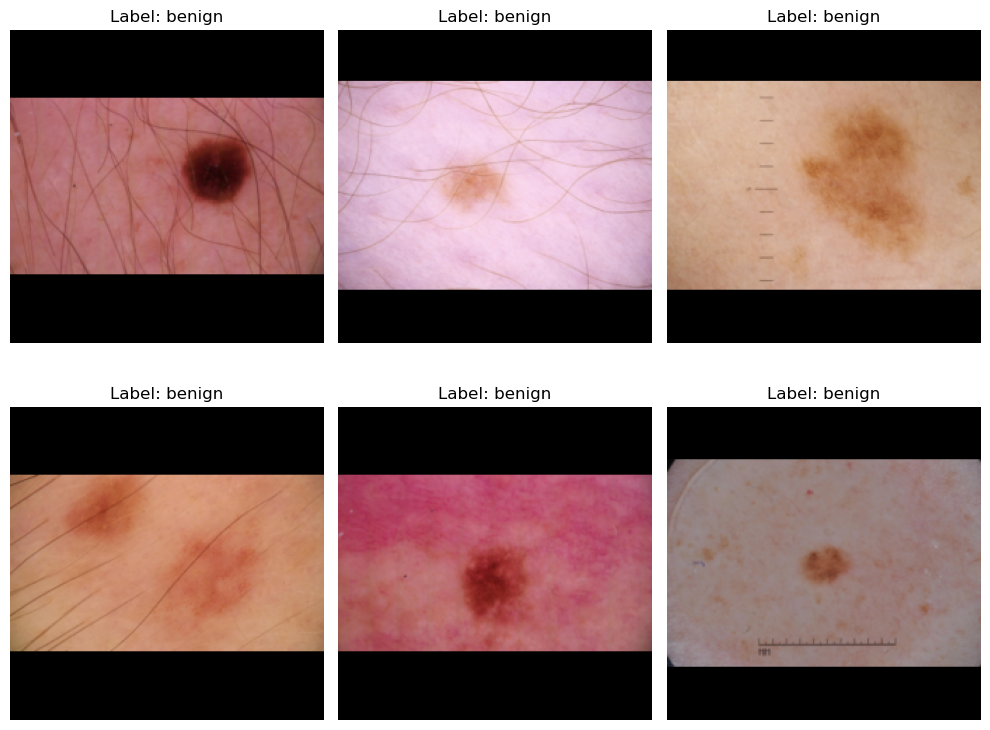

In [17]:
# Show a few samples after padding
sample_rows = filtered_metadata.sample(6, random_state=42)
plt.figure(figsize=(10, 8))
for idx, (_, row) in enumerate(sample_rows.iterrows()):
    with train_zip.open(f"train/{row['image_name_with_ext']}") as file:
        image = Image.open(BytesIO(file.read())).convert('RGB')
        image = np.array(image)  
    
    img_t = data_transforms(image)
    
    # Undo normalization for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)  
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    
    img_disp = img_t * std + mean          # un-normalize
    img_disp = img_disp.permute(1, 2, 0)   # CHW → HWC
    img_disp = torch.clamp(img_disp, 0, 1) # ensure in [0,1]
    
    # Plot
    plt.subplot(2, 3, idx + 1)
    plt.imshow(img_disp.numpy())
    plt.title(f"Label: {row['benign_malignant']}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Preparing Data for Modeling

- Implemented a custom **PyTorch Dataset** class  
- Loads skin lesion images directly from a ZIP file  
- Applies optional transformations (if provided)  
- Returns:
  - Processed image  
  - Binary label (benign = 0, malignant = 1)  

**Purpose**
- Enable efficient data loading  
- Integrate seamlessly with PyTorch DataLoader  
- Prepare images and labels for model training  

In [18]:
# Load dataset for Resnet50
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, zip_path, folder_name, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.zip_path = zip_path  
        self.folder_name = folder_name
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = f"{self.folder_name}/{row['image_name_with_ext']}"
        
        with zipfile.ZipFile(self.zip_path, 'r') as zip_file:
            with zip_file.open(img_path) as file:
                image = Image.open(BytesIO(file.read())).convert('RGB')
                image = np.array(image)
        
        if self.transform:
            image = self.transform(image)
        
        label = 1 if row['benign_malignant'] == 'malignant' else 0 # Binary labels: malignant = 1, benign = 0 
        return image, label


In [19]:
# Load dataset for EfficientNet
class ISICZipDataset(Dataset):
    def __init__(self, dataframe, zip_path, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.zip_path = zip_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Add folder and extension
        filename = f"train/{row['image_name']}.jpg"  

        with zipfile.ZipFile(self.zip_path, 'r') as z:
            with z.open(filename) as f:
                image = Image.open(f).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(row['target'], dtype=torch.float32)

In [20]:
# Split Train & Validation - 80/20 ratio @ seed 42 for reproducibility
if not filtered_metadata.empty:
    train_df, val_df = train_test_split(
        filtered_metadata, test_size=0.2, stratify=filtered_metadata['benign_malignant'], random_state=42)

    print("\nTraining Set Size:", len(train_df))
    print("Validation Set Size:", len(val_df))



Training Set Size: 26500
Validation Set Size: 6626


# Feature Engineering #2

**Training Pipeline**
- Apply resizing with padding (from Feature Engineering #1)  
- Perform data augmentation:
  - Random horizontal/vertical flips  
  - Random rotation  
  - Color jitter (brightness, contrast, etc.)  
- Convert images to tensors  
- Apply ImageNet normalization  
  - Mean: [0.485, 0.456, 0.406]  
  - Std: [0.229, 0.224, 0.225]  

**Purpose of Augmentation**
- Artificially increase data diversity & improve model generalization  
- Learn robust, invariant features to:
  - Rotation  
  - Flipping  
  - Lighting variations  
- Reduce overfitting  

**Validation & Test Pipeline**
- Apply resizing and normalization only  
- Do NOT apply augmentation  
- Ensure stable and unbiased model evaluation  

In [21]:
# Training transforms (with augmentation)
train_transforms_resnet = transforms.Compose([
    transforms.ToPILImage(),
    ResizeWithPadding(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

# Validation/Test transforms (NO augmentation)
val_transforms_resnet = transforms.Compose([
    transforms.ToPILImage(),
    ResizeWithPadding(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])


In [22]:
train_transform_effinet = transforms.Compose([
    ResizeWithPadding(380),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

val_transform_effinet = transforms.Compose([
    ResizeWithPadding(380),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

## Handling Class Imbalance

- Dataset is highly imbalanced:
  - ~2% malignant (positive class)  
  - ~98% benign (negative class)  

**Strategy: WeightedRandomSampler (PyTorch)**

- Convert labels to binary:
  - Malignant = 1  
  - Benign = 0  
- Count number of samples per class  
- Compute class weights using inverse frequency:
  - Weight = 1 / (class count)
  - Malignant frequency is limited to 5x
- Assign higher weights to the minority (malignant) class  

**Sampling Process**
- Sample training examples **with replacement**  
- Minority-class images are selected more frequently  
- Produces a more balanced batch distribution during training  

**Benefit**
- Mitigates bias toward the majority class  
- Improves learning of rare malignant cases  
- Supports more stable and fair model training  

In [23]:
# WeightedRandomSampler 
train_labels = (train_df['benign_malignant'] == 'malignant').astype(int).values # malignant -> 1, benign -> 0
 
max_weight_ratio = 5 # Limit malignant sampling to 5x times compared to benign
class_counts = pd.Series(train_labels).value_counts().sort_index()

class_weights = 1. / class_counts
weight_ratio = class_weights.iloc[1] / class_weights.iloc[0]
if weight_ratio > max_weight_ratio:
    class_weights.iloc[1] = class_weights.iloc[0] * max_weight_ratio

sample_weights = class_weights.values[train_labels]

# Weighted sampler for balanced training
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)

In [24]:
train_zip_path = './Datasets/ISIC_2020_Training_JPEG.zip'  

train_dataset_resnet = SkinLesionDataset(train_df, train_zip_path, 'train', transform=train_transforms_resnet)
val_dataset_resnet   = SkinLesionDataset(val_df, train_zip_path, 'train', transform=val_transforms_resnet)
train_dataset_effinet = ISICZipDataset(train_df, TRAIN_IMAGES_ZIP, transform=train_transform_effinet)
val_dataset_effinet   = ISICZipDataset(val_df,   TRAIN_IMAGES_ZIP, transform=val_transform_effinet)

# Load train & validation dataset
train_loader_resnet  = DataLoader(train_dataset_resnet, batch_size=32, sampler=sampler, num_workers=0, pin_memory=True)
val_loader_resnet   = DataLoader(val_dataset_resnet, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
train_loader_effinet = DataLoader(train_dataset_effinet, batch_size=24, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader_effinet = DataLoader(val_dataset_effinet, batch_size=24, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)


# 2019 Test Data Loader

- The 2020 dataset does not provide publicly available test ground truth labels  
- Therefore, we used the 2019 test dataset as an alternative evaluation set  
  - Total images: 8,238  

**Rationale**
- A well-trained model should generalize to unseen data  
- The 2019 test set serves as an external evaluation benchmark  
- Helps assess real-world generalization performance  

In [25]:
# TEST DATA LOADER for Resnet
class SkinLesionTestDataset_r(Dataset):
    def __init__(self, dataframe, zip_path, folder_name, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.zip_path = zip_path
        self.folder_name = folder_name
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = f"{self.folder_name}/{row['image_name_with_ext']}"
        
        with zipfile.ZipFile(self.zip_path, 'r') as zip_file:
            with zip_file.open(img_path) as file:
                image = Image.open(BytesIO(file.read())).convert('RGB')
                image = np.array(image)
        
        if self.transform:
            image = self.transform(image)
        
        return image 

# Preparing Test set for model evaluation
test_dataset_resnet = SkinLesionTestDataset_r(
    dataframe=test_metadata,
    zip_path='./Datasets/ISIC_2019_Test_Input.zip',
    folder_name='ISIC_2019_Test_Input', 
    transform=val_transforms_resnet)

test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

In [26]:
# TEST DATA LOADER for EfficientNet
class SkinLesionTestDataset_e(Dataset):
    def __init__(self, dataframe, zip_path, folder_name, transform=None, image_col="image"):
        self.df = dataframe.reset_index(drop=True)
        self.zip_path = zip_path
        self.folder_name = folder_name
        self.transform = transform
        self.image_col = image_col

        # ResNet-style: metadata has image id without ".jpg"
        if self.image_col not in self.df.columns:
            raise ValueError(f"Expected column '{self.image_col}' in metadata. Columns: {self.df.columns.tolist()}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.df.iloc[idx][self.image_col]
        img_path = f"{self.folder_name}/{image_id}.jpg"
        with zipfile.ZipFile(self.zip_path, "r") as z:
            with z.open(img_path) as f:
                img = Image.open(BytesIO(f.read())).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

test_dataset_effinet = SkinLesionTestDataset_e(
    dataframe=test_metadata,
    zip_path='./Datasets/ISIC_2019_Test_Input.zip',
    folder_name='ISIC_2019_Test_Input', 
    transform=val_transform_effinet,   
    image_col="image")

test_loader_effinet = DataLoader(test_dataset_effinet, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)


# Baseline Modeling using Random Forest & Custom Feature Extraction

**Model**
- Implemented a classical machine learning baseline: Random Forest  

**Feature Extraction**
- Extracted handcrafted features from raw dermoscopic images  
- Total features: 49  

**Feature Categories**
- Color analysis features  
- Asymmetry quantification features  

**Clinical Motivation**
- Features grounded in established melanoma diagnostic criteria  
- Designed to capture clinically relevant patterns  
- Provide an interpretable baseline for comparison with CNN models  

## Color Features

- Extract **39 color features** from both RGB and LAB color spaces  
- **RGB Features**:
  - Compute per-channel statistics:
    - Mean, Standard deviation, Skewness, Kurtosis, Range, Percentiles, Entropy  
  - Calculated after per-pixel normalization  

- **LAB Features**:
  - Use **a** and **b** channels  
  - Capture perceptually uniform color information  

**Motivation**
- Dataset observations: e.g., red-channel dominance, high-intensity peaks  
- Enables effective differentiation between benign and malignant lesions  
- Provides a comprehensive color-based characterization of lesions  

In [27]:
def extract_color_features(image):
    features = {}

    if isinstance(image, Image.Image):
        image = np.array(image).astype(np.float32)

    # Normalize RGB per pixel 
    rgb_sum = image.sum(axis=2, keepdims=True) + 1e-6
    rgb_norm = image / rgb_sum  # H x W x 3

    # RGB features
    for i, channel in enumerate(['r', 'g', 'b']):
        flat = rgb_norm[:, :, i].flatten()  # use all pixels
        features[f'mean_{channel}'] = np.mean(flat)
        features[f'std_{channel}'] = np.std(flat)
        features[f'range_{channel}'] = np.ptp(flat)
        
        # Skew and kurtosis
        mean = features[f'mean_{channel}']
        std = features[f'std_{channel}']
        if std > 0:
            features[f'skew_{channel}'] = np.mean(((flat - mean) / std) ** 3)
            features[f'kurt_{channel}'] = np.mean(((flat - mean) / std) ** 4) - 3
        else:
            features[f'skew_{channel}'] = 0
            features[f'kurt_{channel}'] = 0

        # Percentiles
        features[f'p25_{channel}'] = np.percentile(flat, 25)
        features[f'p50_{channel}'] = np.percentile(flat, 50)
        features[f'p75_{channel}'] = np.percentile(flat, 75)

        # Entropy
        hist, _ = np.histogram(flat, bins=32, range=(0, 1), density=True)
        hist = hist[hist > 0]
        features[f'entropy_{channel}'] = -np.sum(hist * np.log(hist))

    # Lab features
    lab_image = rgb2lab(image / 255.0)  # skimage expects 0-1
    for i, channel in enumerate(['L', 'a', 'b']):
        flat = lab_image[:, :, i].flatten()
        features[f'mean_{channel}'] = np.mean(flat)
        features[f'std_{channel}'] = np.std(flat)
        features[f'range_{channel}'] = np.ptp(flat)

    return features


## Asymmetry Features

- Extract multi-axis asymmetry features to quantify lesion symmetry  
- Address the **“A” (Asymmetry)** in the ABCDE melanoma rule  
- Motivation: malignant melanomas tend to be more asymmetric  

**Preprocessing**
- Convert images to grayscale  

**Asymmetry Measurements**
- Horizontal asymmetry (compare left vs. right halves)  
- Vertical asymmetry (compare top vs. bottom halves)  
- Diagonal asymmetry (compare opposite quadrants)  

**Statistical Comparisons**
- Mean difference  
- Standard deviation difference  
- Maximum difference  
- Mean absolute difference  

**Final Feature**
- Combine all measurements into an overall asymmetry score  
- Provides a comprehensive indicator of irregular growth patterns  
- Exploratory analysis shows benign lesions are generally more symmetric than malignant lesions  

In [28]:
def extract_asymmetry_features(image):
    features = {}

    if isinstance(image, Image.Image):
        image = np.array(image)

    # Convert to grayscale
    gray = rgb2gray(image) 

    h, w = gray.shape
    mid_h = h // 2
    mid_w = w // 2

    # Horizontal asymmetry
    top = gray[:mid_h, :]
    bottom = np.flipud(gray[h - mid_h:, :])
    h_diff = np.abs(top - bottom)
    features['h_asymmetry_mean'] = np.mean(h_diff)
    features['h_asymmetry_std'] = np.std(h_diff)
    features['h_asymmetry_max'] = np.max(h_diff)

    # Vertical asymmetry
    left = gray[:, :mid_w]
    right = np.fliplr(gray[:, w - mid_w:])
    v_diff = np.abs(left - right)
    features['v_asymmetry_mean'] = np.mean(v_diff)
    features['v_asymmetry_std'] = np.std(v_diff)
    features['v_asymmetry_max'] = np.max(v_diff)

    # Quadrant asymmetry
    q1 = gray[:mid_h, :mid_w]
    q2 = gray[:mid_h, w - mid_w:]
    q3 = gray[h - mid_h:, :mid_w]
    q4 = gray[h - mid_h:, w - mid_w:]

    d1_diff = np.abs(q1 - q4)
    d2_diff = np.abs(q2 - q3)

    features['d1_asymmetry_mean'] = np.mean(d1_diff)
    features['d2_asymmetry_mean'] = np.mean(d2_diff)
    features['overall_asymmetry'] = np.mean([features['h_asymmetry_mean'],features['v_asymmetry_mean'],features['d1_asymmetry_mean'],features['d2_asymmetry_mean']])

    return features


In [29]:
def extract_all_features(image):
    color_feats = extract_color_features(image)
    asymmetry_feats = extract_asymmetry_features(image)
    
    return {**color_feats, **asymmetry_feats}

In [30]:
def load_features_from_dataframe(df, zip_file, folder_name, sample_size=None):
    if sample_size:
        df_sample = (df.groupby('benign_malignant', group_keys=False).apply(lambda x: x.sample(n=min(sample_size, len(x)),replace=False,random_state=42))
                     .reset_index(drop=True))
    else:
        df_sample = df

    features_list, labels = [], []

    with zipfile.ZipFile(zip_file, 'r') as zf:
        for row in tqdm(df_sample.itertuples(index=False),
                        total=len(df_sample),
                        desc="Extracting features"):
            img_path = f"{folder_name}/{row.image_name_with_ext}"
            try:
                with zf.open(img_path) as file:
                    image = Image.open(file).convert('RGB')
                    feats = extract_all_features(image)
                    features_list.append(feats)
                    labels.append(1 if row.benign_malignant == 'malignant' else 0)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

    return pd.DataFrame(features_list), np.array(labels)


# Feature Space Structure: PCA and Clustering

**Goal**
- Explore the structure of the handcrafted feature space  
- Understand whether the engineered lesion features show meaningful organization  

**Methods**
- Principal Component Analysis (PCA)  
- K-means clustering  

**What This Section Examines**
- How much variance is captured by a smaller number of components  
- Whether lesions form natural groupings in feature space  
- Whether some clusters show higher malignant prevalence than others  

**Why It Matters**
- Helps assess redundancy and structure in the handcrafted features  
- Provides an unsupervised view of whether the features capture meaningful lesion differences  
- Offers an interpretable complement to the supervised modeling results  

In [ ]:
# Extract a capped, stratified sample of handcrafted features for PCA and clustering
# features_df, labels = load_features_from_dataframe(train_metadata, './Datasets/ISIC_2020_Training_JPEG.zip', 'train', sample_size=3000)

In [8]:
# Reload previously saved sampled features and labels
# This avoids re-running feature extraction each time the notebook is executed
features_df = pd.read_parquet("./Baseline_PCA/features_sample3000.parquet")
labels = np.load("./Baseline_PCA/labels_sample3000.npy")

print(features_df.shape)
print(len(labels))

(3584, 42)
3584


In [9]:
# Create working copies of the feature matrix and label vector
# This keeps the original loaded data unchanged for later reuse
X = features_df.copy()
y = labels.copy()

In [10]:
# Standardize the handcrafted features before PCA
# PCA is sensitive to feature scale, so we center and scale all variables first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

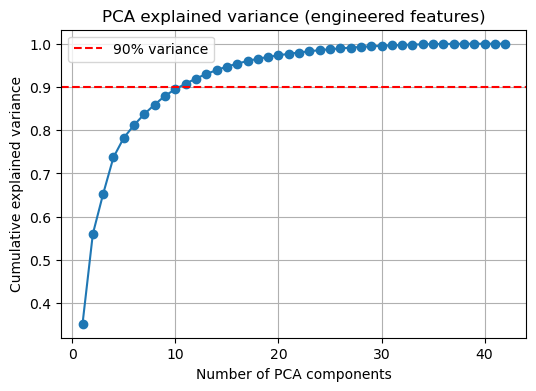

In [11]:
# Fit PCA on the standardized feature matrix
# Then compute cumulative explained variance to see how many components are needed to capture most of the structure in the handcrafted features
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.9, color='red', linestyle='--', label='90% variance')
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance (engineered features)")
plt.legend()
plt.grid(True)
plt.show()

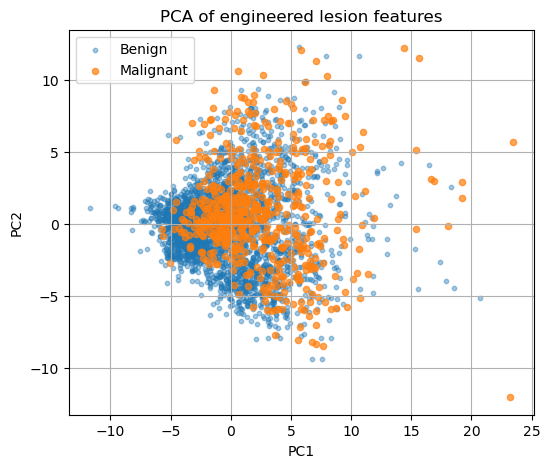

In [12]:
# Project the standardized handcrafted features into 2 principal components
# This provides a low-dimensional view of the feature space for visualization
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca_2[y==0, 0], X_pca_2[y==0, 1],
            s=10, alpha=0.4, label="Benign")
plt.scatter(X_pca_2[y==1, 0], X_pca_2[y==1, 1],
            s=20, alpha=0.7, label="Malignant")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of engineered lesion features")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# Reduce the standardized feature space to 15 principal components before clustering
# This keeps most of the variance while removing noise and redundancy
pca_k = PCA(n_components=15, random_state=42)
X_pca_k = pca_k.fit_transform(X_scaled)

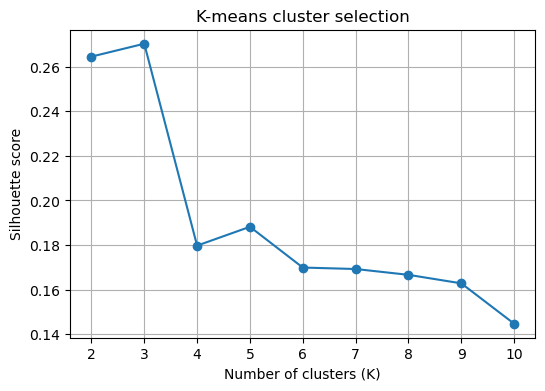

In [14]:
# Evaluate K-means clustering quality across multiple values of K
# Use silhouette score to identify a reasonable number of clusters
sil_scores = []

K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_k = km.fit_predict(X_pca_k)
    sil = silhouette_score(X_pca_k, labels_k)
    sil_scores.append(sil)

plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("K-means cluster selection")
plt.grid(True)
plt.show()


In [15]:
# Select the number of clusters with the highest silhouette score
# Then fit the final K-means model using that chosen value of K
best_k = K_range[np.argmax(sil_scores)]
print("Chosen K:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_pca_k)


Chosen K: 3


In [16]:
# Build a summary table for the discovered clusters
# For each cluster, report the number of samples and the malignant rate
cluster_df = pd.DataFrame({
    "cluster": cluster_labels,
    "label": y
})

summary = (
    cluster_df
    .groupby("cluster")
    .agg(
        count=("label", "size"),
        malignant_rate=("label", "mean")
    )
    .sort_values("malignant_rate", ascending=False)
)

summary


,count,malignant_rate
cluster,,
1,724,0.298343
0,811,0.193588
2,2049,0.102977


## Interpretation of PCA and Clustering Results

**Sampling Note**
- To explore the handcrafted feature space, we applied PCA and K-means clustering to a stratified sample of the training data  
- Because the full dataset is highly imbalanced (about 1.8\% malignant), we used a capped sampling strategy of 3000 samples per class  
- This produced a working sample with an overall malignant rate of about 16.3\%  
- This enriched sample was used only for exploratory analysis and does not reflect real-world prevalence  

**Dimensionality Structure (PCA)**
- The cumulative explained variance plot shows that about 90\% of the variance is captured by the first 10-12 principal components  
- This is notable because the original feature set contains nearly 50 engineered features  
- The result suggests substantial redundancy among the handcrafted color and asymmetry descriptors  
- Many RGB, LAB, and asymmetry-based features appear to be correlated, so the intrinsic dimensionality of the feature space is lower than its raw dimensionality  

**Low-Dimensional Separability**
- The 2D PCA projection (PC1 vs. PC2) shows substantial overlap between benign and malignant lesions  
- Malignant samples appear somewhat more dispersed and extend farther into extreme regions of the feature space  
- However, there is no clear low-dimensional linear boundary separating the two classes  
- This suggests that the handcrafted features contain meaningful structure, but do not provide simple low-dimensional class separation on their own  

**Cluster Structure**
- K-means clustering on the PCA-reduced features achieved its highest silhouette score at $K=3$  
- This suggests the presence of three coarse groupings in the handcrafted feature space  
- The silhouette scores were only moderate (about 0.27 at best), so the clusters are not sharply separated  

**Malignancy Enrichment by Cluster**
- Cluster 1: about 29.8\% malignant  
- Cluster 0: about 19.4\% malignant  
- Cluster 2: about 10.3\% malignant  
- Overall sampled baseline: about 16.3\% malignant  

**Takeaway**
- Relative to the sampled baseline, Cluster 1 is enriched for malignant lesions, while Cluster 2 is comparatively lower risk  
- These clusters were identified without using labels, which suggests that unsupervised structure in the engineered feature space aligns with clinically meaningful differences in malignancy prevalence  
- Overall, the handcrafted features appear to capture biologically relevant variation, even though they do not produce clean low-dimensional class separation  
- This helps explain why handcrafted features can support a useful baseline model, while still motivating the use of more expressive image-based deep learning models  

# Random Forest Classifier

**Goal**
- Build a classical machine learning baseline for melanoma classification  
- Evaluate how well handcrafted lesion features perform without deep learning  

**Methods**
- Random Forest classifier with class balancing  
- Train/test split with stratification  
- Evaluation using accuracy, classification metrics, confusion matrix, and ROC-AUC  


In [17]:
# Split the handcrafted feature dataset into training and test sets
# Stratify by label so the class distribution is preserved across both splits
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(features_df, labels, test_size=0.2, random_state=42, stratify=labels)

# Train a Random Forest baseline on the engineered lesion features
# Use class balancing to reduce bias toward the majority benign class
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Fit the model on the training set and generate predictions on the held-out test set
rf.fit(X_train_b, y_train_b)
y_pred = rf.predict(X_test_b)

# Report standard classification metrics for the baseline model
print("Accuracy:", accuracy_score(y_test_b, y_pred))
print("\nClassification Report:\n", classification_report(y_test_b, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_b, y_pred))


Accuracy: 0.8172942817294282

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89       600
           1       0.44      0.43      0.43       117

    accuracy                           0.82       717
   macro avg       0.66      0.66      0.66       717
weighted avg       0.82      0.82      0.82       717


Confusion Matrix:
 [[536  64]
 [ 67  50]]


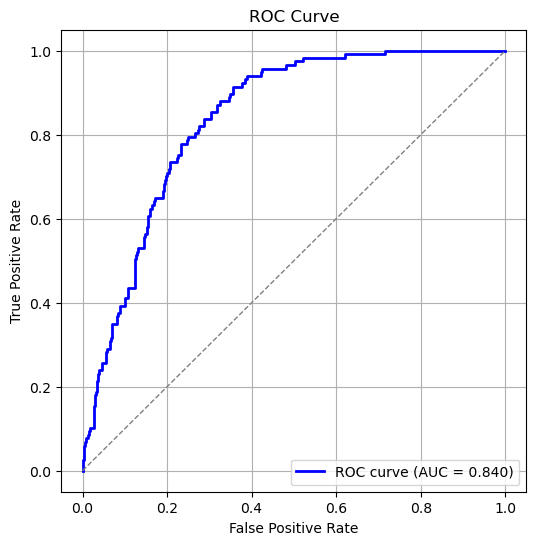

AUC: 0.840


In [18]:
# Predict probabilities 
y_prob = rf.predict_proba(X_test_b)[:, 1]  # probability of class 1 (malignant)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_b, y_prob)
roc_auc = auc(fpr, tpr)

# Display ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.3f}")


## Interpretation and Takeaways

**Observed Performance**
- Accuracy: about 0.82  
- Melanoma precision: about 0.44  
- Melanoma recall: about 0.43  
- Melanoma F1-score: about 0.43  
- ROC-AUC: approximately 0.84  

**Interpretation**
- The Random Forest baseline shows good ranking performance, as reflected by the ROC-AUC of 0.84
- Threshold-based melanoma classification is more modest, with precision and recall both around 0.43  
- This suggests that the handcrafted features contain useful signal, but are still limited in their ability to cleanly separate melanoma from benign lesions at a fixed threshold  

**Why This Section Matters**
- These results show that engineered color and asymmetry features can support a meaningful baseline model  
- At the same time, the gap between ROC-AUC and more moderate classification metrics motivates exploration of more expressive image-based models  

# Deep Learning Model: ResNet-50

**Goal**
- Train a convolutional neural network to classify dermoscopic images as melanoma or non-melanoma  
- Compare learned image features against the handcrafted feature baseline  

**Methods**
- Transfer learning with a pretrained ResNet-50 backbone  
- Standardized image preprocessing, augmentation, and class-imbalance handling  
- Evaluation using ROC-AUC, PR-AUC, and threshold-based classification metrics  

**What This Section Examines**
- Model architecture and training setup  
- Validation performance during training  
- Final classification performance on held-out and external data  

**Why It Matters**
- Deep learning models can learn richer visual representations than handcrafted features alone  
- This section tests whether image-based representation learning improves melanoma detection performance  

## Focal Loss

- **Context:** Only 2% positive (malignant) samples in the dataset  
- **Combined Strategy:** WeightedRandomSampler + Focal Loss  

**WeightedRandomSampler**
- Ensures sufficient positive examples appear in each training batch  
- Helps balance the batch distribution  

**Focal Loss**
- Focuses learning on harder-to-classify positive samples  
- Down-weights easy negative examples  
- Improves model performance under extreme class imbalance  

**Benefit**
- Enables effective learning from rare malignant cases  
- Reduces bias toward the majority class  

In [33]:
# Focal loss - postive class assumes 71% of weight 
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.71, gamma=2):
        super().__init__()
        self.alpha = alpha   # Alpha balances importance between positive and negative classes
        self.gamma = gamma   # Gamma controls how much the loss focuses on hard examples
        self.bce = nn.BCEWithLogitsLoss(reduction='none')   # Keeps per-sample losses

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets) # targets=1 -> alpha, targets=0 -> (1 - alpha)

        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss  # Reduces the loss for easy examples
        return focal_loss.mean()

In [34]:
# Freezing 
def freeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.fc.parameters():
        param.requires_grad = True

# Unfreeze
def unfreeze_model(model):
    for param in model.parameters():
        param.requires_grad = True

In [35]:
# Define training pipeline for one epoch
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)   # Forward pass through the model
            loss = criterion(outputs, labels)  # Compute loss

        scaler.scale(loss).backward() # Back-propagation
        scaler.step(optimizer)  # Update model weights
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)


In [36]:
# Evaluation pipeline
def validate(model, loader, criterion):
    model.eval()

    running_loss = 0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item()
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs) # Compute ROC-AUC using all predictions

    return running_loss / len(loader), auc, all_labels, all_probs

In [37]:
class ResNet50Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision.models import ResNet50_Weights
        backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1) # Load pretrained ResNet50 weights 
        self.cnn = nn.Sequential(*list(backbone.children())[:-1]) # Keep only the convolutional feature extractor

        self.classifier = nn.Sequential(
            nn.Linear(2048, 256),  # ResNet50 outputs 2048 feature channels
            nn.ReLU(),             # Non-linear activation
            nn.Dropout(0.5),       # Regularization 
            nn.Linear(256, 1))      # Single output neuron (binary classification)

    # Pass images through ResNet50 convolutional layers
    def forward(self, image):
        img_features = self.cnn(image)
        img_features = img_features.view(img_features.size(0), -1)
        return self.classifier(img_features)

## ResNet50 Stage 1

**Training Strategy**
- Train only the classifier on top of a **frozen ResNet-50 backbone**  
- Use **Focal Loss** with **alpha = 0.71** to handle class imbalance  

**Checkpointing**
- Configure automatic **resume from checkpoint** on crashes (3–4 hr timeout on Datahub)  
- Restore:
  - Model state, Optimizer state, Scaler state, Best validation AUC, Epoch number  

**Training Procedure**
- Train for **5 epochs**  
- Each epoch:
  - Forward and backward pass via `train_one_epoch`  
  - Validation using `validate` to compute loss and AUC  
  - Save best-performing model based on **validation AUC**  

**GPU Memory Management**
- Call `torch.cuda.empty_cache()` after each epoch  
- Prevents GPU memory accumulation during training  

In [ ]:
model = ResNet50Classifier().to(DEVICE)
for param in model.cnn.parameters():
    param.requires_grad = False
criterion = FocalLoss(alpha=0.71, gamma=2)

# Stage 1: only train classifier head
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()
best_auc = 0
epochs_stage1 = 5
epochs_stage2 = 5
start_epoch = 0

# Resume if checkpoint exists
if os.path.exists("Resnet_final_result/last_resnet50_stage1.pt"):
    checkpoint = torch.load("Resnet_final_result/last_resnet50_stage1.pt", weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])
    best_auc = checkpoint["best_auc"]
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {start_epoch}")

# Stage 1
for epoch in range(start_epoch, epochs_stage1):
    train_loss = train_one_epoch(model, train_loader_resnet, optimizer, criterion, scaler)
    val_loss, val_auc, labels, probs = validate(model, val_loader_resnet, criterion)
    print(f"Stage1 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val AUC: {val_auc:.4f}")
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_auc": best_auc}, "best_resnet50_stage1.pt")
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_auc": best_auc}, "last_resnet50_stage1.pt")
    torch.cuda.empty_cache()

## ResNet50 Stage 2

**Purpose**
- Fine-tune the entire ResNet-50 model after initial classifier training  

**Procedure**
- Call `unfreeze_model(model)` to make all layers trainable  
- Allows backbone to adapt to skin lesion-specific features  

**Optimizer**
- Update to train **all model parameters**  
- Use **lower learning rate**: 1e-5 (vs. 1e-3 in Stage 1)  
  - Prevents large weight updates that could destabilize pretrained features  

**Checkpointing**
- Supports resuming training from checkpoint `last_resnet50_stage2.pt`  
- Restores model, optimizer, scaler states, best validation AUC, and epoch number  

In [25]:
# Fine tuning 
unfreeze_model(model)

optimizer = optim.Adam(model.parameters(), lr=1e-5) # Lower learning rate

start_epoch = 0

if os.path.exists("Resnet_final_result/last_resnet50_stage2.pt"):
    checkpoint = torch.load("Resnet_final_result/last_resnet50_stage2.pt")

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])

    best_auc = checkpoint["best_auc"]
    start_epoch = checkpoint["epoch"] + 1

    print(f"Resuming Stage2 from epoch {start_epoch}")

# Stage 2 Training
for epoch in range(start_epoch, epochs_stage2):

    train_loss = train_one_epoch(model, train_loader_resnet, optimizer, criterion, scaler)
    val_loss, val_auc, labels, probs = validate(model, val_loader_resnet, criterion)

    print(f"Stage2 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_auc": best_auc
        }, "best_resnet50_full.pt")

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_auc": best_auc
    }, "last_resnet50_stage2.pt")

    torch.cuda.empty_cache()

# Save ensemble outputs 
# np.save("val_probs_resnet50.npy", probs)
# np.save("val_labels.npy", labels)


Resuming Stage2 from epoch 5


## Validation Results Summary

**Observed Performance**
- Validation set size: 6626 images  
- ROC-AUC: 0.891  
- PR-AUC: 0.151  
- Positive rate: 1.77\%  

**Interpretation**
- ROC-AUC indicates strong ranking performance overall  
- PR-AUC is more sensitive to the rarity of melanoma and is therefore especially important in this setting  
- The low positive rate highlights the severity of class imbalance in the validation data  

In [26]:
y_true = np.load("Resnet_final_result/val_labels.npy").astype(int)
y_prob = np.load("Resnet_final_result/val_probs_resnet50.npy")

print("Loaded:", y_true.shape, y_prob.shape)
print("Val ROC AUC:", roc_auc_score(y_true, y_prob))
print("Val PR AUC: ", average_precision_score(y_true, y_prob))
print("Val positive rate:", y_true.mean())


Loaded: (6626, 1) (6626, 1)
Val ROC AUC: 0.8872173046393358
Val PR AUC:  0.18751431322740275
Val positive rate: 0.017657712043465137


## Threshold-Based Classification Summary

**Best F1 Threshold**
- Selected threshold: 0.50  

**Confusion Matrix Counts**
- True negatives: 6319  
- False positives: 190  
- False negatives: 75  
- True positives: 42  

**Metrics at This Threshold**
- Precision: 0.181  
- Recall: 0.359  
- F1 score: 0.241  

**Interpretation**
- The model identifies a meaningful subset of melanoma cases, but recall remains limited  
- Precision is modest, reflecting the difficulty of detecting a rare positive class without increasing false positives  
- These results highlight the tradeoff between sensitivity and precision under severe class imbalance  

In [27]:
# Best threshold by F1
thresholds = np.linspace(0.0, 1.0, 101)
f1s = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print("Best threshold by F1:", best_t)

# Report metrics at that threshold
y_pred = (y_prob >= best_t).astype(int)
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:   ", recall_score(y_true, y_pred, zero_division=0))
print("F1:       ", f1_score(y_true, y_pred, zero_division=0))


Best threshold by F1: 0.5
Confusion matrix:
 [[6319  190]
 [  75   42]]
Precision: 0.1810344827586207
Recall:    0.358974358974359
F1:        0.24068767908309455


## External Evaluation on ISIC 2019 Test Set

**Purpose**
- Test how well the ResNet-50 model generalizes to an external dataset  
- Evaluate robustness under cross-dataset shift  

**What This Step Does**
- Generate predictions on the ISIC 2019 test set  
- Compute ranking and classification metrics  
- Compare external performance against validation performance  

**Why It Matters**
- Strong internal validation performance does not guarantee external generalization  
- External testing helps assess whether the learned image features remain reliable across datasets  

In [28]:
# Test set pipeline
def test_probs(model, test_loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for images in test_loader:
            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
    return np.concatenate(all_probs).flatten()

In [30]:
# Load best model for evaluation on test set
checkpoint = torch.load("Resnet_final_result/best_resnet50_full.pt")
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval() 

# test_probs_r = test_probs(model, test_loader, device)
# np.save("test_probs_resnet50.npy", test_probs_r)

ResNet50Classifier(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv

In [7]:
# Read test groundtruth & test probabilities
test_labels = pd.read_csv("./Datasets/ISIC_2019_Test_GroundTruth.csv")
y_true_test = test_labels['MEL'].values  # 1 = melanoma, 0 = not
test_probs_r = np.load("Resnet_final_result/test_probs_resnet50.npy").flatten()


## External Test Set Results Summary

**Observed Performance**
- Test set size: 8238 images  
- ROC-AUC: 0.705  
- Weighted accuracy: 81\%  
- Melanoma precision: 0.25  
- Melanoma recall (sensitivity): 0.69  
- Melanoma F1-score: 0.37  

**Interpretation**
- ResNet-50 shows moderate ranking performance on the external test set  
- Recall is relatively strong, meaning the model identifies many melanoma cases  
- Precision remains low, indicating a substantial number of false positives  
- Overall, the model captures useful signal but remains limited in its ability to detect melanoma reliably under external dataset shift  

In [33]:
# Convert probs to binary predictions (threshold 0.50)
y_pred = (test_probs_r >= 0.50).astype(int)

print(f"AUC: {roc_auc_score(y_true_test, test_probs_r):.4f}")
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred, target_names=['Non-Melanoma', 'Melanoma']))

cm = confusion_matrix(y_true_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"TP (Melanoma correctly detected):     {tp}")
print(f"TN (Non-Melanoma correctly rejected): {tn}")
print(f"FP (Non-Melanoma flagged as Melanoma):{fp}")
print(f"FN (Melanoma missed):                 {fn}")

print(f"\nSensitivity (Recall): {tp/(tp+fn):.4f}")
print(f"Specificity:          {tn/(tn+fp):.4f}")
print(f"Precision:            {tp/(tp+fp):.4f}")


AUC: 0.7048

Classification Report:
              precision    recall  f1-score   support

Non-Melanoma       0.91      0.61      0.73      6911
    Melanoma       0.25      0.69      0.37      1327

    accuracy                           0.62      8238
   macro avg       0.58      0.65      0.55      8238
weighted avg       0.81      0.62      0.67      8238

TP (Melanoma correctly detected):     917
TN (Non-Melanoma correctly rejected): 4209
FP (Non-Melanoma flagged as Melanoma):2702
FN (Melanoma missed):                 410

Sensitivity (Recall): 0.6910
Specificity:          0.6090
Precision:            0.2534


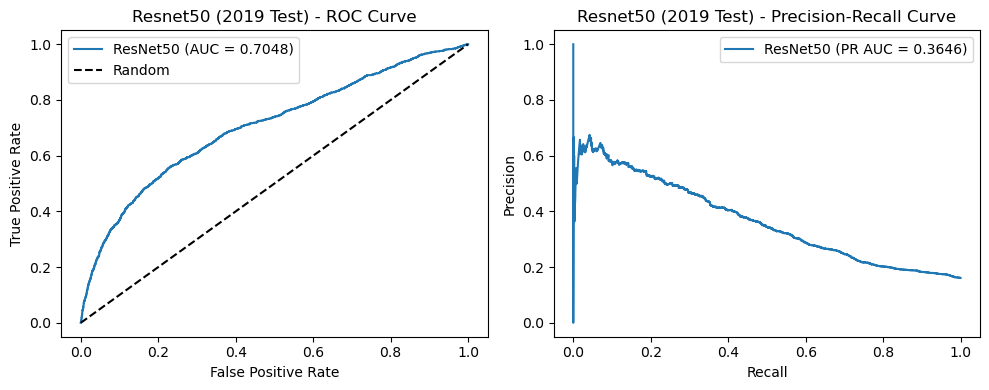

In [8]:
# ROC
fpr, tpr, _ = roc_curve(y_true_test, test_probs_r)
roc_auc = auc(fpr, tpr)

# PR
precision, recall, _ = precision_recall_curve(y_true_test, test_probs_r)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ROC
axes[0].plot(fpr, tpr, label=f'ResNet50 (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Resnet50 (2019 Test) - ROC Curve')
axes[0].legend()

# PR
axes[1].plot(recall, precision, label=f'ResNet50 (PR AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Resnet50 (2019 Test) - Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## ROC and Precision-Recall Curve Interpretation

**Observed Performance**
- ROC-AUC on the ISIC 2019 test set: 0.705  
- PR-AUC on the ISIC 2019 test set: 0.364  

**What the Curves Show**
- ROC-AUC remains meaningfully above chance, indicating that ResNet-50 retains some discriminatory ability on the external dataset  
- However, performance drops compared with the validation ROC-AUC of about 0.88, suggesting reduced generalization under external dataset shift  
- The precision-recall curve is especially informative here because melanoma is a rare positive class  

**Interpretation**
- The PR-AUC of 0.364 is substantially above the validation-set positive rate baseline, indicating that the model captures useful signal for melanoma detection  
- Precision declines as recall increases, showing that identifying more true melanoma cases comes at the cost of more false positives  
- Overall, these curves suggest that ResNet-50 generalizes moderately well, but still faces important limitations in precision and robustness on external data  

# Model #2 - EfficientNetB4

## Model Initialization

- **Device selection**: Chooses CUDA if available, otherwise CPU, and reports the choice for reproducibility. Ideally we want to leverage GPU for training.
- **Backbone**: Loads a pretrained `efficientnet_b4` from `timm`.
- **Head modification**: Replaces the original classifier with a single-output `nn.Linear` layer to support binary classification.
- **Deployment**: Moves the entire model to the selected device, preparing it for training/inference alongside the ResNet component in the ensemble.

In [37]:
model = timm.create_model("efficientnet_b4", pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 1)  # binary classification
model = model.to(DEVICE)

### Loss, Optimizer, and Scaling Setup

- **Class weights**: Computed balanced weights for classes `[0, 1]` using `train_df['target']`, then converted the positive-class weight into a CUDA/CPU tensor (`pos_weight`) to address class imbalance.
- **Loss function**: `nn.BCEWithLogitsLoss` with `pos_weight` to penalize positive examples proportionally more when they are underrepresented.
- **Optimizer**: Adam over all model parameters with a learning rate of `1e-4`.
- **Mixed precision**: `GradScaler()` initialized for automatic mixed-precision training, improving numerical stability and throughput on GPU.

In [39]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['target'])
pos_weight = torch.tensor(weights[1], dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [40]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()

## Training & Checkpointing Workflow

- **Checkpoint infrastructure**
  - Due to remote compute timeouts, incorporated checkpointing so that we could resume training epochs.
  - Creates a `checkpoints/` folder with two targets: `effb4_last.pt` (latest state) and `effb4_best.pt` (best validation ROC-AUC).

- **Validation metric**
  - `evaluate_auc` runs the model in eval mode, gathers sigmoid probabilities, and computes ROC-AUC.

- **Training loop (10 epochs)**
  - Resumes from `effb4_last.pt` if available
  - For each epoch:
    1. Switches to train mode and iterates over `train_loader`.
    2. Moves data to the selected device, casts labels to `(B, 1)`.
    3. Uses mixed precision (`autocast` + `GradScaler`) to compute loss (`BCEWithLogitsLoss`), backprop, and update with Adam.
    4. Tracks average training loss, then evaluates ROC-AUC on the validation loader.

- **Model persistence**
  - Always saves the “last” checkpoint every epoch.
  - Updates the “best” checkpoint only when the new validation AUC beats the previous best (ignoring NaNs), announcing improvements for traceability.

In [44]:
# EfficientNet Train Pipeline
CKPT_LAST = "Effinet_final_result/effb4_last.pt"
CKPT_BEST = "Effinet_final_result/effb4_best.pt"

def save_checkpoint(path, model, optimizer, scaler, epoch, best_auc):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": epoch,              # last completed epoch index
        "best_auc": best_auc
    }, path)

def load_checkpoint(path, model, optimizer=None, scaler=None, device="cpu"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scaler is not None and "scaler_state" in ckpt and ckpt["scaler_state"] is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    start_epoch = ckpt.get("epoch", -1) + 1
    best_auc = ckpt.get("best_auc", -1.0)
    return start_epoch, best_auc

def evaluate_auc(loader):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.numpy().astype(float).tolist()

            logits = model(images)
            probs = torch.sigmoid(logits).squeeze(1).detach().cpu().numpy().tolist()

            all_probs.extend(probs)
            all_labels.extend(labels)

    # If a weird edge case happens where val has only one class (rare w/ stratify), handle safely
    if len(set(all_labels)) < 2:
        return float("nan")
    return roc_auc_score(all_labels, all_probs)

num_epochs = 10

# Resume if last checkpoint exists
start_epoch = 0
best_auc = -1.0
if os.path.exists(CKPT_LAST):
    start_epoch, best_auc = load_checkpoint(CKPT_LAST, model, optimizer, scaler, device=DEVICE)
    print(f"Resuming from {CKPT_LAST} at epoch {start_epoch}, best_auc={best_auc:.4f}")

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)  # shape (B,1)

        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / max(1, len(train_loader))
    val_auc = evaluate_auc(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Val ROC-AUC: {val_auc:.4f}")

    # Always save "last"
    save_checkpoint(CKPT_LAST, model, optimizer, scaler, epoch, best_auc)

    # Save "best" if improved (ignore nan AUC)
    if not np.isnan(val_auc) and val_auc > best_auc:
        best_auc = val_auc
        save_checkpoint(CKPT_BEST, model, optimizer, scaler, epoch, best_auc)
        print(f"New best AUC! Saved to {CKPT_BEST} (best_auc={best_auc:.4f})")

Resuming from Effinet_final_result/effb4_last.pt at epoch 10, best_auc=0.9085


### Validation Artifact Inspection

1. **Load predictions and sanity-check the file system**
   - Loads `val_probs_efficientnet_b4.npy` (model-predicted probabilities) and prints shape, a sample of values, and min/max to ensure the array looks valid.

2. **Load labels and cross-validate lengths**
   - Loads `val_labels_e.npy` (ground-truth targets) and inspects shape and the set of unique labels to confirm it’s binary.
   - Confirms `len(probs) == len(labels)` and matches the `val_dataset` length, guarding against misalignment between predictions and labels.

3. **Class distribution analysis**
   - Computes total counts, malignant/benign totals, and malignant rate to quantify class balance in the validation set.

4. **Probability statistics**
   - Prints overall mean, median, and standard deviation of the probabilities.
   - Splits probabilities by class (benign vs. malignant) and reports class-specific means and medians. Higher malignant probabilities compared to benign ones indicate the model is discriminating as expected.

In [72]:
# ---- Load BEST checkpoint (EffNetB4) for evaluation/inference ----

CKPT_BEST = "Effinet_final_result/effb4_best.pt"
assert os.path.exists(CKPT_BEST), f"Missing checkpoint: {CKPT_BEST}"

ckpt = torch.load(CKPT_BEST, map_location="cpu")

# This prints missing/unexpected keys if something doesn't match
incompat = model.load_state_dict(ckpt["model_state"], strict=True)
print("Loaded CKPT_BEST. strict=True passed.")
print("Checkpoint epoch:", ckpt.get("epoch"), "best_auc:", ckpt.get("best_auc"))

model = model.to(DEVICE)
model.eval()


Loaded CKPT_BEST. strict=True passed.
Checkpoint epoch: 7 best_auc: 0.9084961913353371


EfficientNet(
  (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [47]:
y_true_e = np.load("Effinet_final_result/val_labels_e.npy").astype(int)
y_prob_e = np.load("Effinet_final_result/val_probs_efficientnet_b4.npy")
print("Loaded:", y_true_e.shape, y_prob_e.shape)
print("Val ROC AUC:", roc_auc_score(y_true_e, y_prob_e))
print("Val PR AUC: ", average_precision_score(y_true_e, y_prob_e))
print("Val positive rate:", y_true_e.mean())

Loaded: (6626,) (6626,)
Val ROC AUC: 0.9085040699728056
Val PR AUC:  0.21087962959798948
Val positive rate: 0.017657712043465137


In [48]:
# Best threshold by F1
thresholds = np.linspace(0.0, 1.0, 101)
f1s = [f1_score(y_true_e, (y_prob_e >= t).astype(int), zero_division=0) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print("Best threshold by F1:", best_t)

# Report metrics at that threshold
y_pred_e = (y_prob_e >= best_t).astype(int)
print("Confusion matrix:\n", confusion_matrix(y_true_e, y_pred_e))
print("Precision:", precision_score(y_true_e, y_pred_e, zero_division=0))
print("Recall:   ", recall_score(y_true_e, y_pred_e, zero_division=0))
print("F1:       ", f1_score(y_true_e, y_pred_e, zero_division=0))


Best threshold by F1: 0.88
Confusion matrix:
 [[6442   67]
 [  86   31]]
Precision: 0.3163265306122449
Recall:    0.26495726495726496
F1:        0.28837209302325584


### 2019 Test Evaluation

1. **Dataset prep**
   - Defined paths for the 2019 ISIC test ZIP, metadata, ground truth, and internal folder name.
   - `SkinLesionTestDataset` streams RGB images directly from the ZIP, using IDs from the metadata CSV (expects an `"image"` column). Applies the EfficientNet validation transform (`val_transform`) for consistent 380 × 380 preprocessing.

2. **Loader configuration**
   - `test_loader`: batch size 32, deterministic order (`shuffle=False`), and 4 workers with pinned, persistent workers for throughput.

3. **Model inference**
   - Ensures `artifacts/` exists, switches the EfficientNet-B4 model to eval mode, and disables gradients.
   - Iterates over `test_loader`, runs forward passes, converts logits to sigmoid probabilities, accumulates them, and saves the concatenated array (`float32`) to `artifacts/test_probs_efficientnet_b4_2019.npy`.

4. **Evaluation against ground truth**
   - Loads `ISIC_2019_Test_GroundTruth.csv`, extracts binary MEL labels, and computes ROC-AUC to quantify discrimination performance.
   - Thresholds probabilities at 0.5 to derive class predictions, then prints the confusion matrix `[[TN, FP], [FN, TP]]` for granular error analysis.

5. **Purpose**:  Generates and archives EfficientNet-B4 predictions on the 2019 test set, providing both raw probabilities for ensemble blending and standalone performance metrics (AUC + confusion matrix).


In [ ]:
all_probs = []

with torch.no_grad():
    for images in test_loader_effinet:
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits).view(-1)
        all_probs.append(probs.detach().cpu().numpy())

test_probs_e = np.concatenate(all_probs).astype(np.float32)

np.save("test_probs_efficientnet_b4_2019.npy", test_probs_e)
print("Saved:", "test_probs_efficientnet_b4_2019.npy", "shape:", test_probs_e.shape)

In [12]:
test_probs_e = np.load("Effinet_final_result/test_probs_efficientnet_b4_2019.npy").flatten()

# Convert probs to binary predictions (threshold 0.50)
y_pred_e = (test_probs_e >= 0.88).astype(int)

print(f"AUC: {roc_auc_score(y_true_test, test_probs_e):.4f}")
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_e, target_names=['Non-Melanoma', 'Melanoma']))

cm = confusion_matrix(y_true_test, y_pred_e)
tn, fp, fn, tp = cm.ravel()

print(f"TP (Melanoma correctly detected):     {tp}")
print(f"TN (Non-Melanoma correctly rejected): {tn}")
print(f"FP (Non-Melanoma flagged as Melanoma):{fp}")
print(f"FN (Melanoma missed):                 {fn}")

print(f"\nSensitivity (Recall): {tp/(tp+fn):.4f}")
print(f"Specificity:          {tn/(tn+fp):.4f}")
print(f"Precision:            {tp/(tp+fp):.4f}")


AUC: 0.7017

Classification Report:
              precision    recall  f1-score   support

Non-Melanoma       0.90      0.75      0.82      6911
    Melanoma       0.30      0.55      0.39      1327

    accuracy                           0.72      8238
   macro avg       0.60      0.65      0.60      8238
weighted avg       0.80      0.72      0.75      8238

TP (Melanoma correctly detected):     734
TN (Non-Melanoma correctly rejected): 5195
FP (Non-Melanoma flagged as Melanoma):1716
FN (Melanoma missed):                 593

Sensitivity (Recall): 0.5531
Specificity:          0.7517
Precision:            0.2996


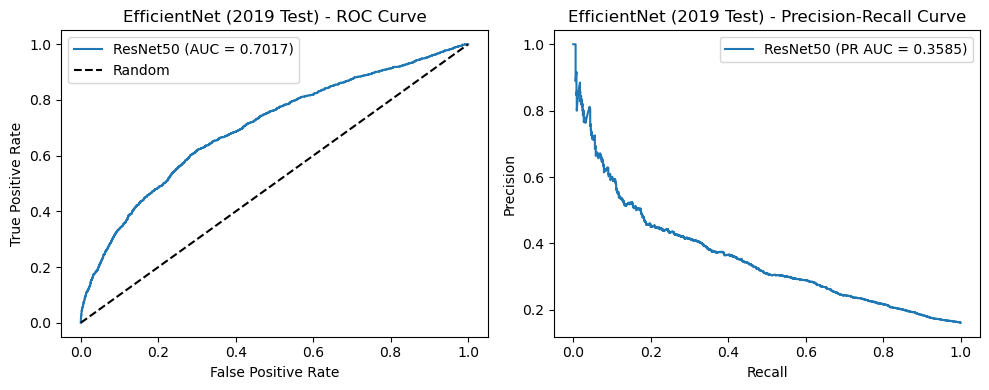

In [10]:
# ROC
fpr, tpr, _ = roc_curve(y_true_test, test_probs_e)
roc_auc = auc(fpr, tpr)

# PR
precision, recall, _ = precision_recall_curve(y_true_test, test_probs_e)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ROC
axes[0].plot(fpr, tpr, label=f'ResNet50 (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('EfficientNet (2019 Test) - ROC Curve')
axes[0].legend()

# PR
axes[1].plot(recall, precision, label=f'ResNet50 (PR AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('EfficientNet (2019 Test) - Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# Ensemble 

# Ensemble Experiments (Validation-First)

This section contains the workflow used to evaluate and construct ensemble models for melanoma classification.

All ensemble design decisions are made **exclusively using the validation set**. This ensures that the external **ISIC 2019 test dataset remains completely untouched until the final evaluation step**, preventing information leakage.

The notebook supports the following ensemble experiments:

- Baseline ensemble evaluation using saved `.npy` validation predictions
- Automated experiment logging and diagnostics
- Multiple fusion strategies:
  - probability averaging
  - rank averaging
  - logit averaging
- Image-based evaluation helpers including:
  - center-biased / geometric cropping
  - test-time augmentation (TTA)
- Utilities for generating new validation predictions from trained **ResNet50** and **EfficientNet-B4** checkpoints

## Important Rule

The **ISIC 2019 dataset must never be used for model selection**.

The following choices must be determined **only using validation data**:

- ensemble method
- ensemble weights
- test-time augmentation strategy
- cropping strategy

Once the best configuration is identified on validation, it is **frozen and evaluated once on the ISIC 2019 dataset** to measure cross-dataset generalization.

In [53]:
# ------------------------------------------------------------
# Configure pandas display settings for experiment diagnostics
# ------------------------------------------------------------
# Increase the maximum number of columns shown when printing
# DataFrames so experiment logs and metric tables are easier
# to inspect during validation analysis.

pd.set_option("display.max_columns", 100)

# Set numerical display precision for clearer comparison of
# evaluation metrics such as ROC-AUC and PR-AUC.
pd.set_option("display.precision", 6)


## 1) File Configuration

This section defines the file paths used throughout the ensemble experiments.

The configuration assumes the following directory structure based on the trained models and saved prediction files:

- **ResNet outputs** are stored in the `Resnet_final_result` directory
- **EfficientNet outputs** are stored in the `Effinet_final_result` directory

The configuration also includes likely locations for shared ISIC dataset resources (training images, metadata, and test files). These paths allow the notebook to rebuild validation dataloaders when running additional experiments such as test-time augmentation (TTA) or cropping.

To make the notebook portable across environments, multiple candidate paths are checked and the first valid location is automatically selected.


In [54]:
# ------------------------------------------------------------
# Path configuration for datasets, checkpoints, and predictions
# ------------------------------------------------------------
# This block defines all file locations used throughout the
# ensemble experiments. Multiple candidate directories are
# checked so the notebook can run in different environments
# (e.g., local machine, shared data mount, or container path).

# Candidate root directories where datasets may be stored
CANDIDATE_ROOTS = [Path('/data'), Path('.'), Path('/mnt/data')]

def first_existing_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    return candidates[0]

def first_existing_file(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return Path(candidates[0])

# Base data directory
DATA_ROOT = first_existing_path(CANDIDATE_ROOTS)

# Model output directories
RESNET_DIR = DATA_ROOT / 'Resnet_final_result'
EFF_CHECKPOINT = DATA_ROOT / 'Effinet_final_result' / 'effb4_best.pt'

# Shared ISIC 2020 training resources
# These are required if we rebuild validation dataloaders for
# experiments such as test-time augmentation or cropping.
TRAIN_IMAGES_ZIP = first_existing_file([
    DATA_ROOT / 'ISIC_2020_Training_JPEG.zip',
    Path('./Datasets/ISIC_2020_Training_JPEG.zip'),
])
TRAIN_METADATA_CSV = first_existing_file([
    DATA_ROOT / 'ISIC_2020_Training_Metadata.csv',
    Path('./Datasets/ISIC_2020_Training_Metadata.csv'),
])

# ISIC 2019 test-set resources (used only for final evaluation)
TEST_2019_ZIP = first_existing_file([
    DATA_ROOT / 'ISIC_2019_Test_Input.zip',
    Path('./Datasets/ISIC_2019_Test_Input.zip'),
])

TEST_2019_METADATA = first_existing_file([
    DATA_ROOT / 'ISIC_2019_Test_Metadata.csv',
    Path('./Datasets/ISIC_2019_Test_Metadata.csv'),
])

TEST_2019_GT = first_existing_file([
    DATA_ROOT / 'ISIC_2019_Test_GroundTruth.csv',
    Path('./Datasets/ISIC_2019_Test_GroundTruth.csv'),
])

TEST_2019_FOLDER_IN_ZIP = 'ISIC_2019_Test_Input'

# Saved prediction files used for ensemble experiments
RESNET_VAL_PROBS = RESNET_DIR / 'val_probs_resnet50.npy'
RESNET_VAL_LABELS = RESNET_DIR / 'val_labels.npy'
RESNET_TEST_PROBS = RESNET_DIR / 'test_probs_resnet50.npy'
RESNET_BEST_CKPT = RESNET_DIR / 'best_resnet50_full.pt'

EFF_VAL_PROBS = 'Effinet_final_result/val_probs_efficientnet_b4.npy'
EFF_VAL_LABELS =  'Effinet_final_result/val_labels_e.npy'
EFF_TEST_PROBS_2019 = 'Effinet_final_result/test_probs_efficientnet_b4_2019.npy'

# Verify that all expected paths exist
# This provides a quick diagnostic before running experiments.
paths_to_check = {
    'DATA_ROOT': DATA_ROOT,
    'RESNET_DIR': RESNET_DIR,
    'TRAIN_IMAGES_ZIP': TRAIN_IMAGES_ZIP,
    'TRAIN_METADATA_CSV': TRAIN_METADATA_CSV,
    'TEST_2019_ZIP': TEST_2019_ZIP,
    'TEST_2019_METADATA': TEST_2019_METADATA,
    'TEST_2019_GT': TEST_2019_GT,
    'RESNET_BEST_CKPT': RESNET_BEST_CKPT,
    'EFF_CHECKPOINT': EFF_CHECKPOINT,
    'RESNET_VAL_PROBS': RESNET_VAL_PROBS,
    'RESNET_VAL_LABELS': RESNET_VAL_LABELS,
    'RESNET_TEST_PROBS': RESNET_TEST_PROBS,
    'EFF_VAL_PROBS': EFF_VAL_PROBS,
    'EFF_VAL_LABELS': EFF_VAL_LABELS,
    'EFF_TEST_PROBS_2019': EFF_TEST_PROBS_2019,
}

for name, p in paths_to_check.items():
    print(f'{name:20s} -> {p} | exists = {Path(p).exists()}')

DATA_ROOT            -> . | exists = True
RESNET_DIR           -> Resnet_final_result | exists = True
TRAIN_IMAGES_ZIP     -> Datasets/ISIC_2020_Training_JPEG.zip | exists = True
TRAIN_METADATA_CSV   -> Datasets/ISIC_2020_Training_Metadata.csv | exists = True
TEST_2019_ZIP        -> Datasets/ISIC_2019_Test_Input.zip | exists = True
TEST_2019_METADATA   -> Datasets/ISIC_2019_Test_Metadata.csv | exists = True
TEST_2019_GT         -> Datasets/ISIC_2019_Test_GroundTruth.csv | exists = True
RESNET_BEST_CKPT     -> Resnet_final_result/best_resnet50_full.pt | exists = True
EFF_CHECKPOINT       -> Effinet_final_result/effb4_best.pt | exists = True
RESNET_VAL_PROBS     -> Resnet_final_result/val_probs_resnet50.npy | exists = True
RESNET_VAL_LABELS    -> Resnet_final_result/val_labels.npy | exists = True
RESNET_TEST_PROBS    -> Resnet_final_result/test_probs_resnet50.npy | exists = True
EFF_VAL_PROBS        -> Effinet_final_result/val_probs_efficientnet_b4.npy | exists = True
EFF_VAL_LABELS     

## 2) Load Validation Predictions

To begin the ensemble experiments, we first load the **saved validation predictions** produced by the trained ResNet50 and EfficientNet-B4 models.

Using saved prediction arrays allows us to evaluate different ensemble strategies **without retraining or rerunning the neural networks**, making experimentation faster and more reproducible.

All ensemble design decisions in this section are made **exclusively using the validation predictions**. The external ISIC 2019 test dataset is intentionally excluded at this stage to avoid information leakage.

In [55]:
# ------------------------------------------------------------
# Load baseline validation predictions from trained models
# ------------------------------------------------------------
# These prediction arrays were generated previously by the
# trained ResNet50 and EfficientNet-B4 models and saved to
# disk as .npy files. Loading them here allows us to evaluate
# ensemble strategies without rerunning the models.

probs_r = np.load(RESNET_VAL_PROBS)
labels_r = np.load(RESNET_VAL_LABELS)

probs_e = np.load(EFF_VAL_PROBS)
labels_e = np.load(EFF_VAL_LABELS)

# Flatten prediction arrays for consistent metric computation
# ------------------------------------------------------------
# Some saved outputs may contain extra dimensions (e.g. shape
# [N,1]). Reshaping ensures that predictions and labels are
# stored as simple 1D arrays before computing ensemble scores.

probs_r_flat = np.asarray(probs_r).reshape(-1)
probs_e_flat = np.asarray(probs_e).reshape(-1)
labels_r_flat = np.asarray(labels_r).reshape(-1)
labels_e_flat = np.asarray(labels_e).reshape(-1)

# Display shapes to verify prediction consistency
# ------------------------------------------------------------
# This diagnostic check confirms that both models produced
# predictions for the same number of validation samples.

print("ResNet val probs shape:", probs_r.shape, "-> flat:", probs_r_flat.shape)
print("ResNet val labels shape:", labels_r.shape, "-> flat:", labels_r_flat.shape)
print("EffNet val probs shape:", probs_e.shape, "-> flat:", probs_e_flat.shape)
print("EffNet val labels shape:", labels_e.shape, "-> flat:", labels_e_flat.shape)

ResNet val probs shape: (6626, 1) -> flat: (6626,)
ResNet val labels shape: (6626, 1) -> flat: (6626,)
EffNet val probs shape: (6626,) -> flat: (6626,)
EffNet val labels shape: (6626,) -> flat: (6626,)


In [56]:
# ------------------------------------------------------------
# Verify label alignment between model prediction files
# ------------------------------------------------------------
# Before constructing an ensemble, we must ensure that both
# models generated predictions for the *same validation samples
# in the same order*. If the label arrays differ, it indicates
# that the prediction files are misaligned (e.g., shuffled or
# generated from different validation splits), which would
# invalidate the ensemble evaluation.

same_labels = np.array_equal(labels_r_flat, labels_e_flat)

print("Labels aligned:", same_labels)
# If the labels do not match, print diagnostic information
# to help identify where the mismatch occurs.
if not same_labels:
    mismatch_count = np.sum(labels_r_flat != labels_e_flat)
    print("Mismatch count:", mismatch_count)
    print("First 20 ResNet labels:", labels_r_flat[:20])
    print("First 20 EffNet labels:", labels_e_flat[:20])
    raise ValueError("Validation labels are not aligned. Stop and fix ordering before ensembling.")

# If labels are aligned, create a single shared label array that will be used for all ensemble metric computations.
val_labels = labels_r_flat.copy()

# Report the positive class prevalence (melanoma rate) in the validation set, which provides context for interpreting PR-AUC.
print("Positive rate:", val_labels.mean())

Labels aligned: True
Positive rate: 0.017657712


## 3) Helper Functions for Ensemble Experiments

This section defines a set of reusable helper utilities used throughout the ensemble experiments. These functions support:

- experiment diagnostics and reporting
- experiment logging for reproducibility
- probability, rank, and logit-based ensemble strategies
- automated weight sweeps to identify the best ensemble configuration
- a reusable experiment runner to evaluate and record results

These utilities allow all ensemble experiments to be conducted in a **consistent and reproducible manner** using only the validation predictions.


In [57]:
# ============================================================
# Experiment logging configuration
# ============================================================
# This section initializes a persistent experiment log used to
# track results from all ensemble experiments. Each experiment
# records the individual model performance, correlation between
# model predictions, and the best ensemble configuration found.


EXPERIMENT_LOG_CSV = Path('Ensemble_result/ensemble_experiment_log.csv')

LOG_COLUMNS = [
    'Experiment',
    'ResNet ROC-AUC',
    'ResNet PR-AUC',
    'EffNet ROC-AUC',
    'EffNet PR-AUC',
    'Correlation',
    'Mean Disagreement',
    'Best Ensemble Type',
    'Best Weight (ResNet)',
    'Best Validation ROC-AUC',
    'Best Validation PR-AUC',
]

# If an experiment log already exists, load it so new results
# append to the previous experiments. Otherwise create an empty
# dataframe with the expected columns.

if 'experiment_log' in globals() and isinstance(experiment_log, pd.DataFrame):
    experiment_log = experiment_log.reindex(columns=LOG_COLUMNS)
elif EXPERIMENT_LOG_CSV.exists():
    experiment_log = pd.read_csv(EXPERIMENT_LOG_CSV)
    experiment_log = experiment_log.reindex(columns=LOG_COLUMNS)
else:
    experiment_log = pd.DataFrame(columns=LOG_COLUMNS)

# Utility: Save experiment log to disk
def save_experiment_log(path=EXPERIMENT_LOG_CSV):
    global experiment_log
    experiment_log = experiment_log.reindex(columns=LOG_COLUMNS)
    experiment_log.to_csv(path, index=False)
    print(f'Saved experiment log -> {path}')

# Utility: Display experiment results sorted by performance
def display_experiment_log():
    if len(experiment_log) == 0:
        return experiment_log
    return experiment_log.sort_values('Best Validation ROC-AUC', ascending=False).reset_index(drop=True)

# Utility: Insert or update an experiment row    
def upsert_experiment_row(row_dict):
    global experiment_log
    row_df = pd.DataFrame([row_dict]).reindex(columns=LOG_COLUMNS)
    if len(experiment_log) > 0 and row_dict['Experiment'] in set(experiment_log['Experiment']):
        experiment_log = experiment_log[experiment_log['Experiment'] != row_dict['Experiment']].copy()
    experiment_log = pd.concat([experiment_log, row_df], ignore_index=True)
    save_experiment_log()

print(f'Existing experiment log rows: {len(experiment_log)}')
display_experiment_log()


# Metric helper functions
def pr_auc_score_safe(y_true, y_score):
    return average_precision_score(y_true, y_score)

def summarize_single_model(name, y_true, probs):
    roc = roc_auc_score(y_true, probs)
    pr = pr_auc_score_safe(y_true, probs)
    print(f'{name} ROC-AUC: {roc:.6f}')
    print(f'{name} PR-AUC : {pr:.6f}')
    return roc, pr

# Ensemble helper functions
def clip_probs(p, eps=1e-6):
    return np.clip(np.asarray(p).reshape(-1), eps, 1 - eps)

def weighted_prob_average(probs_r, probs_e, w):
    return w * probs_r + (1 - w) * probs_e

def weighted_rank_average(probs_r, probs_e, w):
    rank_r = rankdata(probs_r) / len(probs_r)
    rank_e = rankdata(probs_e) / len(probs_e)
    return w * rank_r + (1 - w) * rank_e

def weighted_logit_average(probs_r, probs_e, w):
    pr = clip_probs(probs_r)
    pe = clip_probs(probs_e)
    zr = logit(pr)
    ze = logit(pe)
    z = w * zr + (1 - w) * ze
    return expit(z)

# Select ensemble strategy
def combine_with_method(probs_r, probs_e, method, w):
    if method == 'Probability':
        return weighted_prob_average(probs_r, probs_e, w)
    elif method == 'Rank':
        return weighted_rank_average(probs_r, probs_e, w)
    elif method == 'Logit':
        return weighted_logit_average(probs_r, probs_e, w)
    else:
        raise ValueError(f'Unknown method: {method}')

# Weight sweep utility
#Evaluate ensemble performance across a grid of weights to identify the best ResNet/EfficientNet contribution.
def sweep_weights(y_true, probs_r, probs_e, method_name, weights=None):
    if weights is None:
        weights = np.linspace(0, 1, 101)

    best = {
        'method': method_name,
        'weight': None,
        'roc_auc': -np.inf,
        'pr_auc': -np.inf,
        'preds': None,
    }

    for w in weights:
        preds = combine_with_method(probs_r, probs_e, method_name, w)
        roc = roc_auc_score(y_true, preds)
        pr = pr_auc_score_safe(y_true, preds)

        if roc > best['roc_auc']:
            best.update({
                'weight': float(w),
                'roc_auc': float(roc),
                'pr_auc': float(pr),
                'preds': preds,
            })

    return best



def run_ensemble_experiment(name, probs_r, probs_e, labels, save_csv=True):

    """
    Run a complete validation-based ensemble experiment.

    This function:
    1. evaluates the individual ResNet50 and EfficientNet-B4 predictions,
    2. measures similarity between the two models' outputs,
    3. sweeps ensemble weights for probability, rank, and logit averaging,
    4. identifies the best-performing ensemble method on the validation set,
    5. records the experiment summary in the persistent log.

    Parameters
    ----------
    name : str
        Descriptive name for the experiment.
    probs_r : array-like
        Validation probabilities from the ResNet50 model.
    probs_e : array-like
        Validation probabilities from the EfficientNet-B4 model.
    labels : array-like
        Ground-truth validation labels aligned to both prediction arrays.
    save_csv : bool, optional
        Reserved for compatibility with the experiment workflow. The
        experiment log is updated through `upsert_experiment_row()`.

    Returns
    -------
    dict
        Dictionary containing the best result for each ensemble method
        and the overall best validation configuration.
    """    
    global experiment_log

    # Ensure all inputs are 1D arrays before computing metrics
    probs_r = np.asarray(probs_r).reshape(-1)
    probs_e = np.asarray(probs_e).reshape(-1)
    labels = np.asarray(labels).reshape(-1)

    # Print experiment header for easier notebook navigation
    print('\n' + '=' * 40)
    print(f'Experiment: {name}')
    print('=' * 40)

     # Evaluate each model individually on the validation set
    roc_r, pr_r = summarize_single_model('ResNet', labels, probs_r)
    roc_e, pr_e = summarize_single_model('EffNet', labels, probs_e)

    # Quantify how similar the two models' predictions are
    # --------------------------------------------------------
    # Correlation measures agreement in ranking behavior, while
    # mean absolute disagreement measures average prediction gap.
    corr = float(np.corrcoef(probs_r, probs_e)[0, 1])
    disagree = float(np.mean(np.abs(probs_r - probs_e)))

    print(f'Prediction correlation : {corr:.6f}')
    print(f'Mean disagreement      : {disagree:.6f}')

    # Sweep ensemble weights for each fusion strategy
    # --------------------------------------------------------
    # Each method searches for the ResNet/EfficientNet weighting
    # that gives the strongest validation ROC-AUC.
    prob_best = sweep_weights(labels, probs_r, probs_e, 'Probability')
    rank_best = sweep_weights(labels, probs_r, probs_e, 'Rank')
    logit_best = sweep_weights(labels, probs_r, probs_e, 'Logit')

    # Select the strongest ensemble configuration overall
    all_best = [prob_best, rank_best, logit_best]
    overall_best = max(all_best, key=lambda d: d['roc_auc'])

    for result in all_best:
        print('\n---', result['method'], 'averaging ---')
        print(f"Best weight (ResNet): {result['weight']:.2f}")
        print(f"Best ROC-AUC        : {result['roc_auc']:.6f}")
        print(f"Best PR-AUC         : {result['pr_auc']:.6f}")

    print('\n>>> Overall winner')
    print(f"Method              : {overall_best['method']}")
    print(f"Best weight (ResNet): {overall_best['weight']:.2f}")
    print(f"Best ROC-AUC        : {overall_best['roc_auc']:.6f}")
    print(f"Best PR-AUC         : {overall_best['pr_auc']:.6f}")

    # Save experiment summary to the persistent log
    upsert_experiment_row({
        'Experiment': name,
        'ResNet ROC-AUC': roc_r,
        'ResNet PR-AUC': pr_r,
        'EffNet ROC-AUC': roc_e,
        'EffNet PR-AUC': pr_e,
        'Correlation': corr,
        'Mean Disagreement': disagree,
        'Best Ensemble Type': overall_best['method'],
        'Best Weight (ResNet)': overall_best['weight'],
        'Best Validation ROC-AUC': overall_best['roc_auc'],
        'Best Validation PR-AUC': overall_best['pr_auc'],
    })
    
    # Return the full set of method-specific results so later
    # cells can inspect or reuse them without rerunning sweeps.
    return {
        'probability': prob_best,
        'rank': rank_best,
        'logit': logit_best,
        'overall_best': overall_best,
    }


Existing experiment log rows: 1


## 4) Run the baseline validation ensemble

This experiment evaluates ensemble performance using the **saved validation predictions** from the trained ResNet50 and EfficientNet-B4 models.

No additional augmentations or preprocessing are applied here. The purpose of this baseline experiment is to establish the reference ensemble performance before testing alternative strategies such as test-time augmentation (TTA) or center-cropping.

All ensemble weights and methods are selected using the **validation set only**, following the validation-first protocol described earlier.


In [58]:
# Baseline ensemble experiment using saved validation outputs
# ------------------------------------------------------------
# This experiment combines the stored validation predictions
# from ResNet50 and EfficientNet-B4 without any additional
# augmentations or cropping. It serves as the reference
# ensemble performance for later experiments.

baseline_results = run_ensemble_experiment(
    name="Baseline (saved validation predictions)",
    probs_r=probs_r_flat,
    probs_e=probs_e_flat,
    labels=val_labels,
)

# Display experiment results sorted by validation ROC-AUC
experiment_log.sort_values("Best Validation ROC-AUC", ascending=False)


Experiment: Baseline (saved validation predictions)
ResNet ROC-AUC: 0.887217
ResNet PR-AUC : 0.187514
EffNet ROC-AUC: 0.908504
EffNet PR-AUC : 0.210880
Prediction correlation : 0.541639
Mean disagreement      : 0.121058

--- Probability averaging ---
Best weight (ResNet): 0.10
Best ROC-AUC        : 0.914367
Best PR-AUC         : 0.225771

--- Rank averaging ---
Best weight (ResNet): 0.35
Best ROC-AUC        : 0.918937
Best PR-AUC         : 0.228078

--- Logit averaging ---
Best weight (ResNet): 0.66
Best ROC-AUC        : 0.919730
Best PR-AUC         : 0.227759

>>> Overall winner
Method              : Logit
Best weight (ResNet): 0.66
Best ROC-AUC        : 0.919730
Best PR-AUC         : 0.227759
Saved experiment log -> Ensemble_result/ensemble_experiment_log.csv


,Experiment,ResNet ROC-AUC,ResNet PR-AUC,EffNet ROC-AUC,EffNet PR-AUC,Correlation,Mean Disagreement,Best Ensemble Type,Best Weight (ResNet),Best Validation ROC-AUC,Best Validation PR-AUC
0,Baseline (saved validation predictions),0.887217,0.187514,0.908504,0.21088,0.541639,0.121058,Logit,0.66,0.91973,0.227759


## 5) Rebuild the validation loaders and model objects

To perform augmentation experiments (TTA and cropping), we must regenerate validation predictions directly from the trained model checkpoints.

This section reconstructs the model architectures and validation data loaders used during training so that new validation predictions can be generated consistently.

### EfficientNet-B4 image-only configuration
- Data split: `train_test_split(..., test_size=0.2, stratify=df["target"], random_state=42)`
- Input resolution: **380 × 380**
- Validation transform: resize-with-padding to 380, followed by ImageNet normalization
- Checkpoint format: dictionary containing `"model_state"`

### ResNet50 image-only configuration
- Data split: `train_test_split(..., test_size=0.2, stratify=filtered_metadata["benign_malignant"], random_state=42)`
- Input resolution: **224 × 224**
- Validation transform: resize-with-padding to 224, followed by ImageNet normalization
- Checkpoint format: dictionary containing `"model_state_dict"`

### Important verification step

Before generating augmented predictions, we first regenerate **baseline validation predictions** from the checkpoints and compare them with the saved `.npy` predictions.

Matching results confirm that:

- the validation split is correct
- the dataloader ordering is consistent
- the checkpoints are loaded correctly

Only after this verification step do we generate predictions for:

- test-time augmentation (TTA)
- center-cropped images
- combined crop + TTA experiments

In [60]:

# Model builders and flexible checkpoint loading utilities
# ============================================================
# These utilities reconstruct the trained ResNet50 and
# EfficientNet-B4 architectures and load the corresponding
# checkpoint weights used during training.

class ResNet50ImageOnlyWrapper(nn.Module):

    """
    ResNet50 architecture adapted for binary melanoma
    classification using image inputs only.
    """
    def __init__(self, dropout=0.3):
        super().__init__()

        # Load ResNet50 backbone and remove the final classification layer
        base = models.resnet50(weights=None)
        self.cnn = nn.Sequential(*list(base.children())[:-1])

         # Custom classification head used during training
        self.classifier = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x.squeeze(1)

# Build ResNet50 model
def build_resnet50_image_only_model():
    return ResNet50ImageOnlyWrapper(dropout=0.3)

# Build EfficientNet-B4 model
def build_effnet_b4_image_only_model(device=DEVICE):
    model = timm.create_model("efficientnet_b4", pretrained=False)
     # Replace classifier head for binary classification
    model.classifier = nn.Linear(model.classifier.in_features, 1)
    return model.to(device)

# Extract state dictionary from checkpoints

def extract_state_dict(ckpt):
    if not isinstance(ckpt, dict):
        return ckpt
    for key in ["model_state_dict", "model_state", "state_dict", "model"]:
        if key in ckpt:
            return ckpt[key]
    return ckpt

# Flexible checkpoint loader

def load_checkpoint_flex(model, checkpoint_path, device=DEVICE, strict=True):
    checkpoint_path = Path(checkpoint_path)
    assert checkpoint_path.exists(), f"Missing checkpoint: {checkpoint_path}"
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = extract_state_dict(ckpt)
    incompat = model.load_state_dict(state_dict, strict=strict)
    model = model.to(device)
    model.eval()
    print(f"Loaded: {checkpoint_path}")
    if isinstance(ckpt, dict):
        interesting = {k: ckpt.get(k) for k in ['epoch', 'best_auc'] if k in ckpt}
        if interesting:
            print("Checkpoint metadata:", interesting)
    if hasattr(incompat, "missing_keys"):
        print("Missing keys   :", incompat.missing_keys)
        print("Unexpected keys:", incompat.unexpected_keys)
    return model, ckpt

# Instantiate models and load trained checkpoints
resnet_model = build_resnet50_image_only_model()
resnet_model, resnet_ckpt = load_checkpoint_flex(resnet_model, RESNET_BEST_CKPT, device=DEVICE, strict=True)

effnet_model = build_effnet_b4_image_only_model()
effnet_model, effnet_ckpt = load_checkpoint_flex(effnet_model, EFF_CHECKPOINT, device=DEVICE, strict=True)


Loaded: Resnet_final_result/best_resnet50_full.pt
Checkpoint metadata: {'epoch': 3, 'best_auc': 0.8906156236007211}
Missing keys   : []
Unexpected keys: []
Loaded: Effinet_final_result/effb4_best.pt
Checkpoint metadata: {'epoch': 7, 'best_auc': 0.9084961913353371}
Missing keys   : []
Unexpected keys: []


## 6) Prediction helpers for baseline, TTA, and center-crop experiments

The helper functions in the following cells generate validation predictions under multiple evaluation settings. These utilities allow us to systematically compare different inference strategies while keeping all model-selection decisions restricted to the validation set.

Specifically, these helpers allow us to:

- regenerate baseline validation predictions directly from the trained checkpoints
- verify that regenerated predictions match the saved `.npy` baseline outputs
- generate predictions using test-time augmentation (TTA)
- generate predictions using lesion-centered cropping
- generate predictions using combined crop + TTA evaluation

Maintaining this workflow ensures that all ensemble design choices are made **only on the validation set**, preventing information leakage from the external ISIC 2019 test dataset.


## 7) Recommended experiment workflow

After confirming that regenerated baseline predictions match the saved validation outputs, the following experiments can be performed.

Suggested evaluation order:

1. **TTA-only evaluation**  
2. **Center-crop-only evaluation**  
3. **Center-crop + TTA evaluation**

Each experiment generates a new set of validation predictions that can be evaluated using the ensemble framework defined earlier.

Importantly, **all decisions regarding ensemble type, model weighting, cropping strategy, and augmentation should be finalized using validation performance only** before evaluating the final configuration on the ISIC 2019 test dataset.

In [61]:
# Prediction helpers for baseline, TTA, and center-crop experiments
# ============================================================
# These functions generate validation predictions directly from
# trained checkpoints under different inference settings:
#   - baseline inference
#   - center-crop evaluation
#   - test-time augmentation (TTA)
#   - combined crop + TTA evaluation
#
# They are used to regenerate validation predictions so that
# ensemble choices can be made using validation data only.

def center_crop_tensor(images, crop_frac=0.90):
    """
    Center-crop a batch of tensors and resize back to original spatial size.
    """
    if crop_frac >= 1.0:
        return images

    b, c, h, w = images.shape
    new_h = max(1, int(round(h * crop_frac)))
    new_w = max(1, int(round(w * crop_frac)))

    top = (h - new_h) // 2
    left = (w - new_w) // 2

    cropped = images[:, :, top:top + new_h, left:left + new_w]
    
    # Resize back to the original input size so the model can
    # process the cropped images without changing architecture.
    resized = F.interpolate(cropped, size=(h, w), mode="bilinear", align_corners=False)
    return resized

def apply_tta_views(images, tta_mode="basic"):

    """
    Resize back to the original input size so the model can
    process the cropped images without changing architecture.
    
    """
    if tta_mode not in {"none", "light", "basic", "eight"}:
        raise ValueError("tta_mode must be one of: 'none', 'light', 'basic', 'eight'")

    views = [images]
    if tta_mode == "none":
        return views

    if tta_mode == "light":
        views.append(torch.flip(images, dims=[3]))  # horizontal flip only
        return views

    # Basic TTA views
    views.append(torch.flip(images, dims=[3]))
    views.append(torch.flip(images, dims=[2]))
    views.append(torch.rot90(images, k=2, dims=[2, 3]))

    if tta_mode == "eight":
         # Additional rotations and reflected variants
        r90 = torch.rot90(images, k=1, dims=[2, 3])
        r270 = torch.rot90(images, k=3, dims=[2, 3])
        views.extend([r90, r270, torch.flip(r90, dims=[3]), torch.flip(r90, dims=[2])])

    return views

@torch.no_grad()
def predict_probs_from_model(model, loader, device=DEVICE, crop_frac=1.0, tta_mode="none", verbose=True):
    
    """
    Generate probability predictions from a model under a specified
    inference configuration.

    This function supports:
    - baseline inference
    - center-crop inference
    - test-time augmentation (TTA)
    - combined crop + TTA inference

    For each batch:
    1. images are optionally center-cropped,
    2. TTA views are generated,
    3. the model predicts each view,
    4. probabilities are averaged across views.
    """
    model.eval()
    all_probs = []
    all_labels = []

    total_batches = len(loader)

    for batch_idx, batch in enumerate(loader):
        # Expect loader output in the form (images, labels, ...)
        if isinstance(batch, (list, tuple)) and len(batch) >= 2:
            images, labels = batch[0], batch[1]
        else:
            raise ValueError("Loader must yield at least (images, labels).")
            
         # Apply lesion-centered cropping before generating TTA views
        images = images.to(device)
        labels = labels.to(device).float().view(-1)

        images = center_crop_tensor(images, crop_frac=crop_frac)
        views = apply_tta_views(images, tta_mode=tta_mode)

        probs_per_view = []

        # Run inference for each augmented view
        for view in views:
            logits = model(view)
            probs = torch.sigmoid(logits).view(-1)
            probs_per_view.append(probs)

        # Average probabilities across all TTA views
        mean_probs = torch.stack(probs_per_view, dim=0).mean(dim=0)

        all_probs.append(mean_probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        if verbose and ((batch_idx + 1) % 25 == 0 or (batch_idx + 1) == total_batches):
            print(f"Processed batch {batch_idx + 1}/{total_batches}")

    probs = np.concatenate(all_probs).reshape(-1)
    labels = np.concatenate(all_labels).reshape(-1)

    if verbose:
        print(f"Generated predictions | crop_frac={crop_frac} | tta_mode={tta_mode}")
        print("Shape:", probs.shape, labels.shape)

    return probs, labels

def compare_against_saved_baseline(name, generated_probs, saved_probs, generated_labels, saved_labels, atol=1e-6, rtol=1e-5):
     """
    Compare regenerated baseline predictions against the previously
    saved `.npy` baseline predictions.

    This is a critical sanity check before running augmentation-based
    experiments. Strong agreement confirms that:
    - the validation split is correct,
    - the dataloader ordering is correct,
    - the checkpoint was loaded correctly.

    """
    generated_probs = np.asarray(generated_probs).reshape(-1)
    saved_probs = np.asarray(saved_probs).reshape(-1)
    generated_labels = np.asarray(generated_labels).reshape(-1)
    saved_labels = np.asarray(saved_labels).reshape(-1)

    print(f"\n{name} baseline sanity check")
    print("-" * 40)
    print("Labels aligned:", np.array_equal(generated_labels, saved_labels))
    print("Same length    :", len(generated_probs) == len(saved_probs))

    max_abs_diff = float(np.max(np.abs(generated_probs - saved_probs)))
    mean_abs_diff = float(np.mean(np.abs(generated_probs - saved_probs)))
    corr = float(np.corrcoef(generated_probs, saved_probs)[0, 1])
    close = np.allclose(generated_probs, saved_probs, atol=atol, rtol=rtol)

    print(f"Prediction correlation with saved baseline: {corr:.8f}")
    print(f"Mean abs diff                         : {mean_abs_diff:.8e}")
    print(f"Max abs diff                          : {max_abs_diff:.8e}")
    print("np.allclose(...)                      :", close)

    if not np.array_equal(generated_labels, saved_labels):
        raise ValueError(f"{name}: labels do not align with the saved baseline.")
    return {
        "labels_aligned": True,
        "prediction_corr": corr,
        "mean_abs_diff": mean_abs_diff,
        "max_abs_diff": max_abs_diff,
        "allclose": close,
    }


In [ ]:

# --- TTA ONLY (validation) ---

#------------------------------------------------------------
# Save generated validation predictions (disabled by default)
# ------------------------------------------------------------
# During development, TTA and crop experiments generated new
# validation prediction arrays which were saved to disk to
# avoid recomputing expensive inference runs.
#
# These lines are left commented out in the final notebook
# because the saved `.npy` outputs are already included and
# used directly in the ensemble experiments.


# Start with tta_mode="basic". Only try "eight" if "basic" looks promising.

# probs_resnet_tta, labels_resnet_tta = predict_probs_from_model(
#     model=resnet_model,
#     loader=resnet_val_loader,
#     device=DEVICE,
#     crop_frac=1.0,
#     tta_mode="light",
# )
# probs_effnet_tta, labels_effnet_tta = predict_probs_from_model(
#     model=effnet_model,
#     loader=effnet_val_loader,
#     device=DEVICE,
#     crop_frac=1.0,
#     tta_mode="light",
# )

# assert np.array_equal(labels_resnet_tta, val_labels)
# assert np.array_equal(labels_effnet_tta, val_labels)

# tta_results = run_ensemble_experiment(
#     name="TTA only (basic)",
#     probs_r=probs_resnet_tta,
#     probs_e=probs_effnet_tta,
#     labels=val_labels,
# )
# experiment_log.sort_values("Best Validation ROC-AUC", ascending=False)



# np.save("val_probs_resnet_tta.npy", probs_resnet_tta)
# np.save("val_probs_effnet_tta.npy", probs_effnet_tta)

In [ ]:

# # --- CENTER CROP ONLY (validation) ---

#------------------------------------------------------------
# Save generated validation predictions (disabled by default)
# ------------------------------------------------------------
# During development, TTA and crop experiments generated new
# validation prediction arrays which were saved to disk to
# avoid recomputing expensive inference runs.
#
# These lines are left commented out in the final notebook
# because the saved `.npy` outputs are already included and
# used directly in the ensemble experiments.


# # 0.90 is a conservative first choice. You can also compare 0.95 and 0.85 later.

# CROP_FRAC = 0.90

# probs_resnet_crop, labels_resnet_crop = predict_probs_from_model(
#     model=resnet_model,
#     loader=resnet_val_loader,
#     device=DEVICE,
#     crop_frac=CROP_FRAC,
#     tta_mode="none",
# )
# probs_effnet_crop, labels_effnet_crop = predict_probs_from_model(
#     model=effnet_model,
#     loader=effnet_val_loader,
#     device=DEVICE,
#     crop_frac=CROP_FRAC,
#     tta_mode="none",
# )

# assert np.array_equal(labels_resnet_crop, val_labels)
# assert np.array_equal(labels_effnet_crop, val_labels)

# crop_results = run_ensemble_experiment(
#     name=f"Center crop only (crop_frac={CROP_FRAC})",
#     probs_r=probs_resnet_crop,
#     probs_e=probs_effnet_crop,
#     labels=val_labels,
# )
# experiment_log.sort_values("Best Validation ROC-AUC", ascending=False)




# np.save("val_probs_resnet_crop.npy", probs_resnet_crop)
# np.save("val_probs_effnet_crop.npy", probs_effnet_crop)

In [ ]:

# # --- CENTER CROP + TTA (validation) ---

#------------------------------------------------------------
# Save generated validation predictions (disabled by default)
# ------------------------------------------------------------
# During development, TTA and crop experiments generated new
# validation prediction arrays which were saved to disk to
# avoid recomputing expensive inference runs.
#
# These lines are left commented out in the final notebook
# because the saved `.npy` outputs are already included and
# used directly in the ensemble experiments.

# CROP_FRAC = 0.90

# probs_resnet_crop_tta, labels_resnet_crop_tta = predict_probs_from_model(
#     model=resnet_model,
#     loader=resnet_val_loader,
#     device=DEVICE,
#     crop_frac=CROP_FRAC,
#     tta_mode="basic",
# )
# probs_effnet_crop_tta, labels_effnet_crop_tta = predict_probs_from_model(
#     model=effnet_model,
#     loader=effnet_val_loader,
#     device=DEVICE,
#     crop_frac=CROP_FRAC,
#     tta_mode="basic",
# )

# assert np.array_equal(labels_resnet_crop_tta, val_labels)
# assert np.array_equal(labels_effnet_crop_tta, val_labels)

# crop_tta_results = run_ensemble_experiment(
#     name=f"Center crop + TTA (crop_frac={CROP_FRAC}, tta=basic)",
#     probs_r=probs_resnet_crop_tta,
#     probs_e=probs_effnet_crop_tta,
#     labels=val_labels,
# )
# experiment_log.sort_values("Best Validation ROC-AUC", ascending=False)

# np.save("val_probs_resnet_crop_tta.npy", probs_resnet_crop_tta)
# np.save("val_probs_effnet_crop_tta.npy", probs_effnet_crop_tta)

### Archived validation experiment results

During earlier clean validation runs, we compared baseline ensembling against TTA-only, center-crop-only, and center-crop+TTA variants. The live experiment log in this notebook was later affected by logging inconsistencies, so the screenshots below are included as archival evidence of the validation results used to choose the final frozen configuration.

**Comparison 1: baseline vs. TTA-only vs. center-crop-only**

![Validation experiment archive 1](validation_archive_1.png)

**Comparison 2: baseline vs. center-crop+TTA**

![Validation experiment archive 2](validation_archive_2.png)

These archived validation results indicate that:

- **TTA only (basic)** achieved the strongest validation ROC-AUC among the tested configurations.
- **Center cropping** did not improve performance.
- **Center crop + TTA** also underperformed relative to the baseline ensemble.

Based on these comparisons, we froze the final validation-selected configuration as:
- TTA mode: `basic`
- crop fraction: `1.0` (no center crop)
- ensemble method: `Logit`
- ResNet weight: `0.73`

## 8) Freeze the winning validation configuration

After completing all validation-only experiments, the final ensemble configuration must be selected **using validation performance only**.

Recommended steps:



Once the configuration is finalized, **freeze these settings** and apply them exactly once to the ISIC 2019 test dataset.  
No additional tuning should be performed using the test data.

## 9) Final frozen evaluation on the ISIC 2019 test set

This section performs the **final evaluation on the ISIC 2019 test dataset** using the configuration selected from the validation experiments.

Important: the test dataset must **not** be used for tuning any model or ensemble parameters.  
All hyperparameters—including ensemble method, model weights, cropping strategy, and TTA configuration—must be chosen **exclusively using validation results** from the ISIC 2020 dataset.

The following configuration represents the best-performing setup identified during validation:

- `BEST_TTA_MODE = "basic"`
- `BEST_CROP_FRAC = 1.0` (no center cropping)
- `BEST_ENSEMBLE_METHOD = "logit"`
- `BEST_WEIGHT_RESNET = 0.73`




In [66]:
# Frozen ensemble configuration selected from validation
# ------------------------------------------------------------
# These parameters represent the chosen frozen configuration 
# for final evaluation.
# They are now "frozen" and applied once to the ISIC 2019
# test set for final evaluation.

BEST_TTA_MODE = 'basic'
BEST_CROP_FRAC = 1.0
BEST_ENSEMBLE_METHOD = 'Logit'
BEST_WEIGHT_RESNET = 0.73

print('Frozen config:')
print('  TTA mode            :', BEST_TTA_MODE)
print('  Crop frac           :', BEST_CROP_FRAC)
print('  Ensemble method     :', BEST_ENSEMBLE_METHOD)
print('  ResNet ensemble wt  :', BEST_WEIGHT_RESNET)
print('  EffNet ensemble wt  :', 1 - BEST_WEIGHT_RESNET)


Frozen config:
  TTA mode            : basic
  Crop frac           : 1.0
  Ensemble method     : Logit
  ResNet ensemble wt  : 0.73
  EffNet ensemble wt  : 0.27


In [67]:
# Build ISIC 2019 test datasets and dataloaders
# ------------------------------------------------------------
# This cell prepares the external ISIC 2019 evaluation data
# used for the final frozen ensemble test. The dataset is read
# directly from the test-image ZIP archive, then aligned with
# the corresponding metadata and melanoma ground-truth labels.

class Load2019ZipDataset(Dataset):
    """
    Dataset wrapper for reading ISIC 2019 test images directly
    from a ZIP archive.

    Each sample returns:
    - the transformed dermoscopic image
    - the binary melanoma label (MEL)
    """
    def __init__(self, dataframe, zip_path, folder_name='ISIC_2019_Test_Input', transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.zip_path = str(zip_path)
        self.folder_name = folder_name
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = f"{self.folder_name}/{row['image']}.jpg"
        with zipfile.ZipFile(self.zip_path, 'r') as zf:
            with zf.open(filename) as f:
                image = Image.open(BytesIO(f.read())).convert('RGB')
                image = np.array(image)
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(float(row['MEL']), dtype=torch.float32)
        return image, label

# Load ISIC 2019 metadata and ground-truth labels
test_2019_meta = pd.read_csv(TEST_2019_METADATA)
test_2019_gt = pd.read_csv(TEST_2019_GT)

# Keep only the image identifier and melanoma label, then
# merge with metadata so the final DataFrame preserves the
# expected image ordering for evaluation.
test_2019_df = test_2019_meta.merge(test_2019_gt[['image', 'MEL']], on='image', how='inner')
test_2019_df = test_2019_df.copy()

print('2019 metadata rows:', len(test_2019_meta))
print('2019 GT rows      :', len(test_2019_gt))
print('2019 merged rows  :', len(test_2019_df))
print('2019 MEL rate     :', test_2019_df['MEL'].mean())

# Build model-specific test datasets
# ------------------------------------------------------------
# Separate datasets are created because ResNet50 and
# EfficientNet-B4 use different validation/test transforms.

resnet_test_2019_dataset = Load2019ZipDataset(
    dataframe=test_2019_df,
    zip_path=TEST_2019_ZIP,
    folder_name=TEST_2019_FOLDER_IN_ZIP,
    transform=val_transforms_resnet,
)
effnet_test_2019_dataset = Load2019ZipDataset(
    dataframe=test_2019_df,
    zip_path=TEST_2019_ZIP,
    folder_name=TEST_2019_FOLDER_IN_ZIP,
    transform=val_transform_effinet,
)

# Build deterministic dataloaders for final evaluation
# ------------------------------------------------------------
# Shuffle is disabled so predictions remain aligned across
# both models, which is essential for correct ensembling.

resnet_test_2019_loader = DataLoader(resnet_test_2019_dataset, batch_size=4, shuffle=False, num_workers=0, pin_memory=False)
effnet_test_2019_loader = DataLoader(effnet_test_2019_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

print('len(resnet_test_2019_loader):', len(resnet_test_2019_loader))
print('len(effnet_test_2019_loader):', len(effnet_test_2019_loader))


2019 metadata rows: 8238
2019 GT rows      : 8238
2019 merged rows  : 8238
2019 MEL rate     : 0.16108278708424376
len(resnet_test_2019_loader): 2060
len(effnet_test_2019_loader): 515


In [ ]:
# Optional: Generate frozen ISIC 2019 test predictions
# ------------------------------------------------------------
# This block was used to generate the final frozen test-set
# predictions directly from the ResNet50 and EfficientNet-B4
# checkpoints using the validation-selected ensemble settings.
#
# It is left commented out in the final notebook because the
# saved prediction files are already available and rerunning
# full test inference is unnecessary for submission.
#
# These predictions should only be generated *after* the final
# ensemble configuration has been selected on the validation set.


# probs_resnet_2019, labels_resnet_2019 = predict_probs_from_model(
#     model=resnet_model,
#     loader=resnet_test_2019_loader,
#     device=DEVICE,
#     crop_frac=BEST_CROP_FRAC,
#     tta_mode=BEST_TTA_MODE,
# )

# probs_effnet_2019, labels_effnet_2019 = predict_probs_from_model(
#     model=effnet_model,
#     loader=effnet_test_2019_loader,
#     device=DEVICE,
#     crop_frac=BEST_CROP_FRAC,
#     tta_mode=BEST_TTA_MODE,
# )

# assert np.array_equal(labels_resnet_2019, labels_effnet_2019), 'ResNet/EffNet 2019 labels do not align.'
# y_true_2019 = labels_resnet_2019.astype(int)

# np.save('test_probs_resnet50_2019_frozen.npy', probs_resnet_2019.astype(np.float32))
# np.save('test_probs_effnet_b4_2019_frozen.npy', probs_effnet_2019.astype(np.float32))
# print('Saved frozen 2019 test predictions.')


In [69]:
# Final frozen ensemble evaluation on the ISIC 2019 test set
# ------------------------------------------------------------
# This cell performs the final external evaluation using the
# frozen ensemble configuration selected from validation.
#
# Important:
# - The 2019 test set is used only once at this stage
# - No ensemble tuning is performed here
# - The saved prediction files were generated using the
#   frozen validation-selected settings


# Load frozen test-set probability predictions from each model
probs_resnet_2019 = np.load("Ensemble_result/test_probs_resnet50_2019_frozen.npy").flatten()
probs_effnet_2019 = np.load("Ensemble_result/test_probs_effnet_b4_2019_frozen.npy").flatten()

# Combine model probabilities using the frozen ensemble method
# and frozen ResNet weight selected on the validation set.
test_preds_ens_2019 = combine_with_method(
    probs_resnet_2019,
    probs_effnet_2019,
    method=BEST_ENSEMBLE_METHOD,
    w=BEST_WEIGHT_RESNET,
)

# Compute single-model and ensemble performance on the
# external ISIC 2019 test dataset.
resnet_2019_roc = roc_auc_score(y_true_test, probs_resnet_2019)
resnet_2019_pr = pr_auc_score_safe(y_true_test, probs_resnet_2019)
effnet_2019_roc = roc_auc_score(y_true_test, probs_effnet_2019)
effnet_2019_pr = pr_auc_score_safe(y_true_test, probs_effnet_2019)
ens_2019_roc = roc_auc_score(y_true_test, test_preds_ens_2019)
ens_2019_pr = pr_auc_score_safe(y_true_test, test_preds_ens_2019)

print('2019 TEST RESULTS (FROZEN CONFIG)')
print('-' * 40)
print(f'ResNet ROC-AUC   : {resnet_2019_roc:.6f}')
print(f'ResNet PR-AUC    : {resnet_2019_pr:.6f}')
print(f'EffNet ROC-AUC   : {effnet_2019_roc:.6f}')
print(f'EffNet PR-AUC    : {effnet_2019_pr:.6f}')
print(f'Ensemble method  : {BEST_ENSEMBLE_METHOD}')
print(f'ResNet weight    : {BEST_WEIGHT_RESNET:.2f}')
print(f'Ensemble ROC-AUC : {ens_2019_roc:.6f}')
print(f'Ensemble PR-AUC  : {ens_2019_pr:.6f}')



# Store final results in a compact table for reporting and
# save them to disk for later reference in the report.
final_2019_results = pd.DataFrame([{
    'Split': '2019 test (frozen)',
    'ResNet ROC-AUC': resnet_2019_roc,
    'ResNet PR-AUC': resnet_2019_pr,
    'EffNet ROC-AUC': effnet_2019_roc,
    'EffNet PR-AUC': effnet_2019_pr,
    'Ensemble Method': BEST_ENSEMBLE_METHOD,
    'ResNet Weight': BEST_WEIGHT_RESNET,
    'Ensemble ROC-AUC': ens_2019_roc,
    'Ensemble PR-AUC': ens_2019_pr,
}])
final_2019_results.to_csv('Ensemble_result/final_2019_frozen_results.csv', index=False)
final_2019_results


2019 TEST RESULTS (FROZEN CONFIG)
----------------------------------------
ResNet ROC-AUC   : 0.710913
ResNet PR-AUC    : 0.378680
EffNet ROC-AUC   : 0.710362
EffNet PR-AUC    : 0.368056
Ensemble method  : Logit
ResNet weight    : 0.73
Ensemble ROC-AUC : 0.722674
Ensemble PR-AUC  : 0.389825


,Split,ResNet ROC-AUC,ResNet PR-AUC,EffNet ROC-AUC,EffNet PR-AUC,Ensemble Method,ResNet Weight,Ensemble ROC-AUC,Ensemble PR-AUC
0,2019 test (frozen),0.710913,0.37868,0.710362,0.368056,Logit,0.73,0.722674,0.389825
